**LIMPIEZA , TRANSFORMACION Y CREACION DE FEACTURES**

In [28]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Add src to path
sys.path.append(os.path.abspath(os.path.join('..')))

from src.load_data import load_raw_data
from src.preprocess import build_master_table, aggregate_monthly, split_data
from src.features import create_features
from src.models import NaiveModel, train_model, predict_model
from src.evaluation import calculate_metrics
from src.pipeline_simulation import run_monthly_pipeline

%matplotlib inline

## 2. Carga de Datos y Preprocesamiento
Cargamos los datos raw, construimos la tabla maestra (orders) y generamos la serie mensual de ingresos.

Loading orders from /Users/angrysp/Documents/sergioMaestria/m13/MIADAS13/data/dataset/olist_orders_dataset.csv...
Loading payments from /Users/angrysp/Documents/sergioMaestria/m13/MIADAS13/data/dataset/olist_order_payments_dataset.csv...
Loading items from /Users/angrysp/Documents/sergioMaestria/m13/MIADAS13/data/dataset/olist_order_items_dataset.csv...
Loading payments from /Users/angrysp/Documents/sergioMaestria/m13/MIADAS13/data/dataset/olist_order_payments_dataset.csv...
Loading items from /Users/angrysp/Documents/sergioMaestria/m13/MIADAS13/data/dataset/olist_order_items_dataset.csv...
Loading customers from /Users/angrysp/Documents/sergioMaestria/m13/MIADAS13/data/dataset/olist_customers_dataset.csv...
Loading products from /Users/angrysp/Documents/sergioMaestria/m13/MIADAS13/data/dataset/olist_products_dataset.csv...
Loading sellers from /Users/angrysp/Documents/sergioMaestria/m13/MIADAS13/data/dataset/olist_sellers_dataset.csv...
Loading reviews from /Users/angrysp/Documents/se

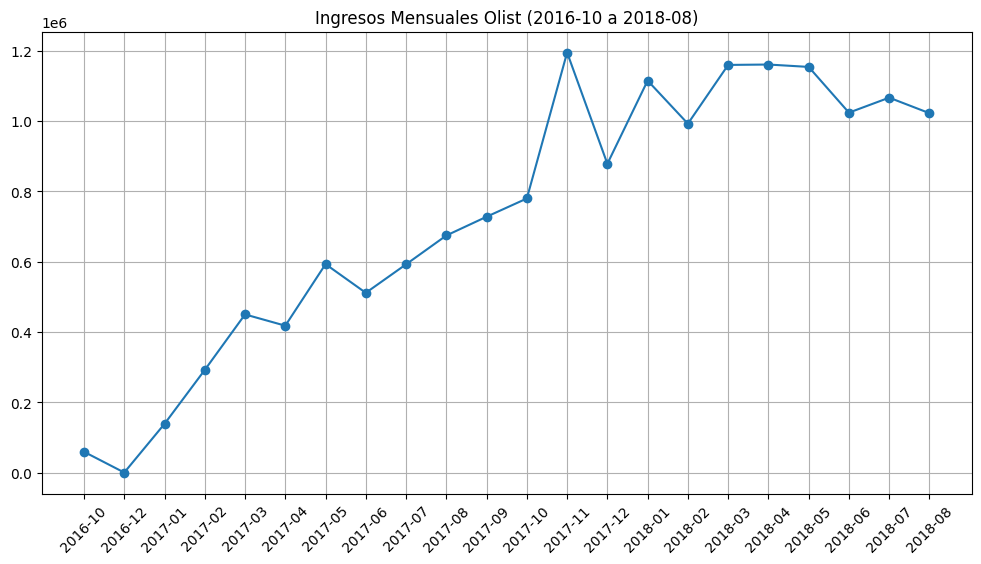

In [19]:
# Cargar datos
data = load_raw_data()

# Construir Master Table (Nivel Orden)
print("Construyendo Master Table...")
master_table = build_master_table(data, save=True)
print(f"Master Table Shape: {master_table.shape}")

# Agregar Mensualmente (Nivel Mes)
monthly_df = aggregate_monthly(master_table)

print(f"Total meses: {len(monthly_df)}")
print(monthly_df.head())

# Visualización
plt.figure(figsize=(12, 6))
plt.plot(monthly_df['year_month'].astype(str), monthly_df['monthly_revenue'], marker='o')
plt.xticks(rotation=45)
plt.title("Ingresos Mensuales Olist (2016-10 a 2018-08)")
plt.grid(True)
plt.show()

## 3. Feature Engineering
Generamos variables temporales, lags y promedios móviles para todas las variables numéricas.

In [20]:
df_features = create_features(monthly_df)
print(f"Features generadas: {df_features.shape[1]}")
print(df_features.columns.tolist()[:20]) # Mostrar primeras 20 columnas

Features generadas: 155
['year_month', 'monthly_revenue', 'total_orders', 'total_items', 'total_freight', 'review_score_mean', 'delivery_time_days', 'delivered_on_time', 'customer_is_repeat', 'product_weight_mean', 'product_volume_mean', 'avg_item_value', 'freight_ratio', 'installments_ratio', 'is_delivered', 'is_canceled', 'month', 'year', 'quarter', 'month_index']


/Users/angrysp/Documents/sergioMaestria/m13/MIADAS13/src/features.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_ma_{window}"] = df[col].shift(1).rolling(window=window).mean()
/Users/angrysp/Documents/sergioMaestria/m13/MIADAS13/src/features.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_ma_{window}"] = df[col].shift(1).rolling(window=window).mean()
/Users/angrysp/Documents/sergioMaestria/m13/MIADAS13/src/features.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the re

## 4. Split Temporal
Dividimos en Train+Val, Backtest y Test Final.

In [21]:
train_val, backtest, final_test = split_data(df_features)

print(f"Train+Val shape: {train_val.shape}")
print(f"Backtest shape: {backtest.shape}")
print(f"Final Test shape: {final_test.shape}")

# Verificar rangos
print(f"Train range: {train_val['year_month'].min()} to {train_val['year_month'].max()}")
print(f"Backtest range: {backtest['year_month'].min()} to {backtest['year_month'].max()}")

Train+Val shape: (18, 155)
Backtest shape: (3, 155)
Final Test shape: (1, 155)
Train range: 2016-10 to 2018-04
Backtest range: 2018-05 to 2018-07


## 5. Modelado y Evaluación (Backtest)

Entrenamos modelos usando solo datos hasta 2018-04 y evaluamos en 2018-05, 06 y 07.

In [22]:
# Preparar datos para entrenamiento
# Eliminamos filas con NaNs (por los lags)
train_clean = train_val.dropna()

target_col = "monthly_revenue"
exclude_cols = ["year_month", target_col, "month_index", "month", "year", "quarter"]
feature_cols = [c for c in train_clean.columns if c not in exclude_cols]

X_train = train_clean[feature_cols]
y_train = train_clean[target_col]

X_backtest = backtest[feature_cols]
y_backtest = backtest[target_col]

# Rellenar NaNs en backtest si existen (por si acaso)
X_backtest = X_backtest.fillna(0)

print(f"Total Features usadas: {len(feature_cols)}")

Total Features usadas: 149


### 5.1 Modelo Naive
Predice el valor del mes anterior (monthly_revenue_lag_1).

In [23]:
naive_model = NaiveModel()
y_pred_naive = naive_model.predict(X_backtest)

metrics_naive = calculate_metrics(y_backtest, y_pred_naive)
print("Métricas Naive:", metrics_naive)

Métricas Naive: {'MAE': 59855.07666666666, 'RMSE': np.float64(79146.74464114929), 'MAPE': np.float64(5.765381726266574), 'Bias': np.float64(31414.909999999993)}


### 5.2 Modelo de Regresión Lineal

In [24]:
lr_model = train_model(X_train, y_train, model_type="linear")
y_pred_lr = predict_model(lr_model, X_backtest)

metrics_lr = calculate_metrics(y_backtest, y_pred_lr)
print("Métricas Linear Regression:", metrics_lr)

Métricas Linear Regression: {'MAE': 477128.05946263653, 'RMSE': np.float64(506157.15359014797), 'MAPE': np.float64(43.668390110954576), 'Bias': np.float64(477128.05946263653)}


### 5.3 Comparación Visual

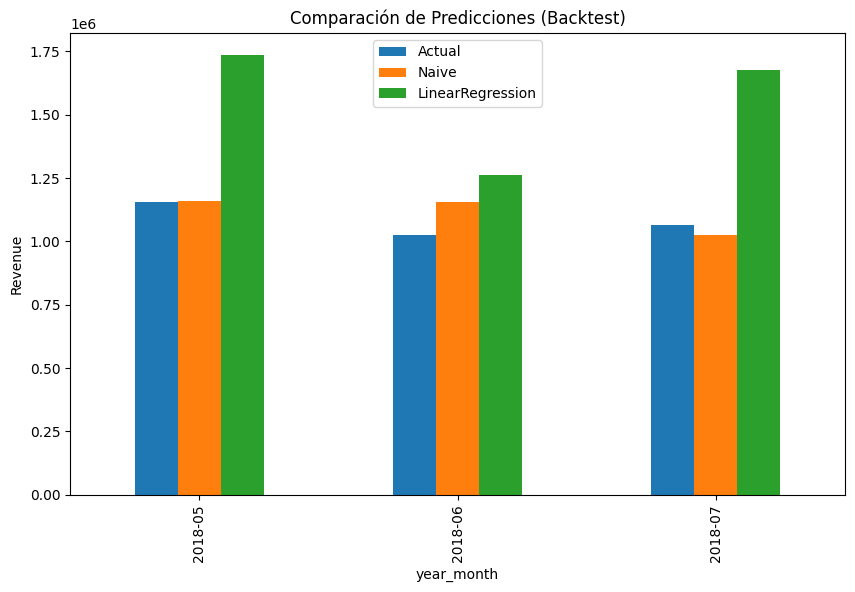

In [25]:
results = pd.DataFrame({
    "year_month": backtest["year_month"].astype(str),
    "Actual": y_backtest,
    "Naive": y_pred_naive,
    "LinearRegression": y_pred_lr
})

results.set_index("year_month").plot(kind="bar", figsize=(10, 6))
plt.title("Comparación de Predicciones (Backtest)")
plt.ylabel("Revenue")
plt.show()

## 6. Selección de Variables
Analizamos la correlación para ver qué variables son más importantes.

🔍 Analizando matriz de correlación...
✅ Dataset cargado (Train Split): 6 filas, 155 columnas

📊 Preparando datos para análisis de correlación...
📈 Columnas numéricas para correlación: 154

🧮 Calculando matriz de correlación...


🔍 Analizando matriz de correlación...
✅ Dataset cargado (Train Split): 6 filas, 155 columnas

📊 Preparando datos para análisis de correlación...
📈 Columnas numéricas para correlación: 154

🧮 Calculando matriz de correlación...


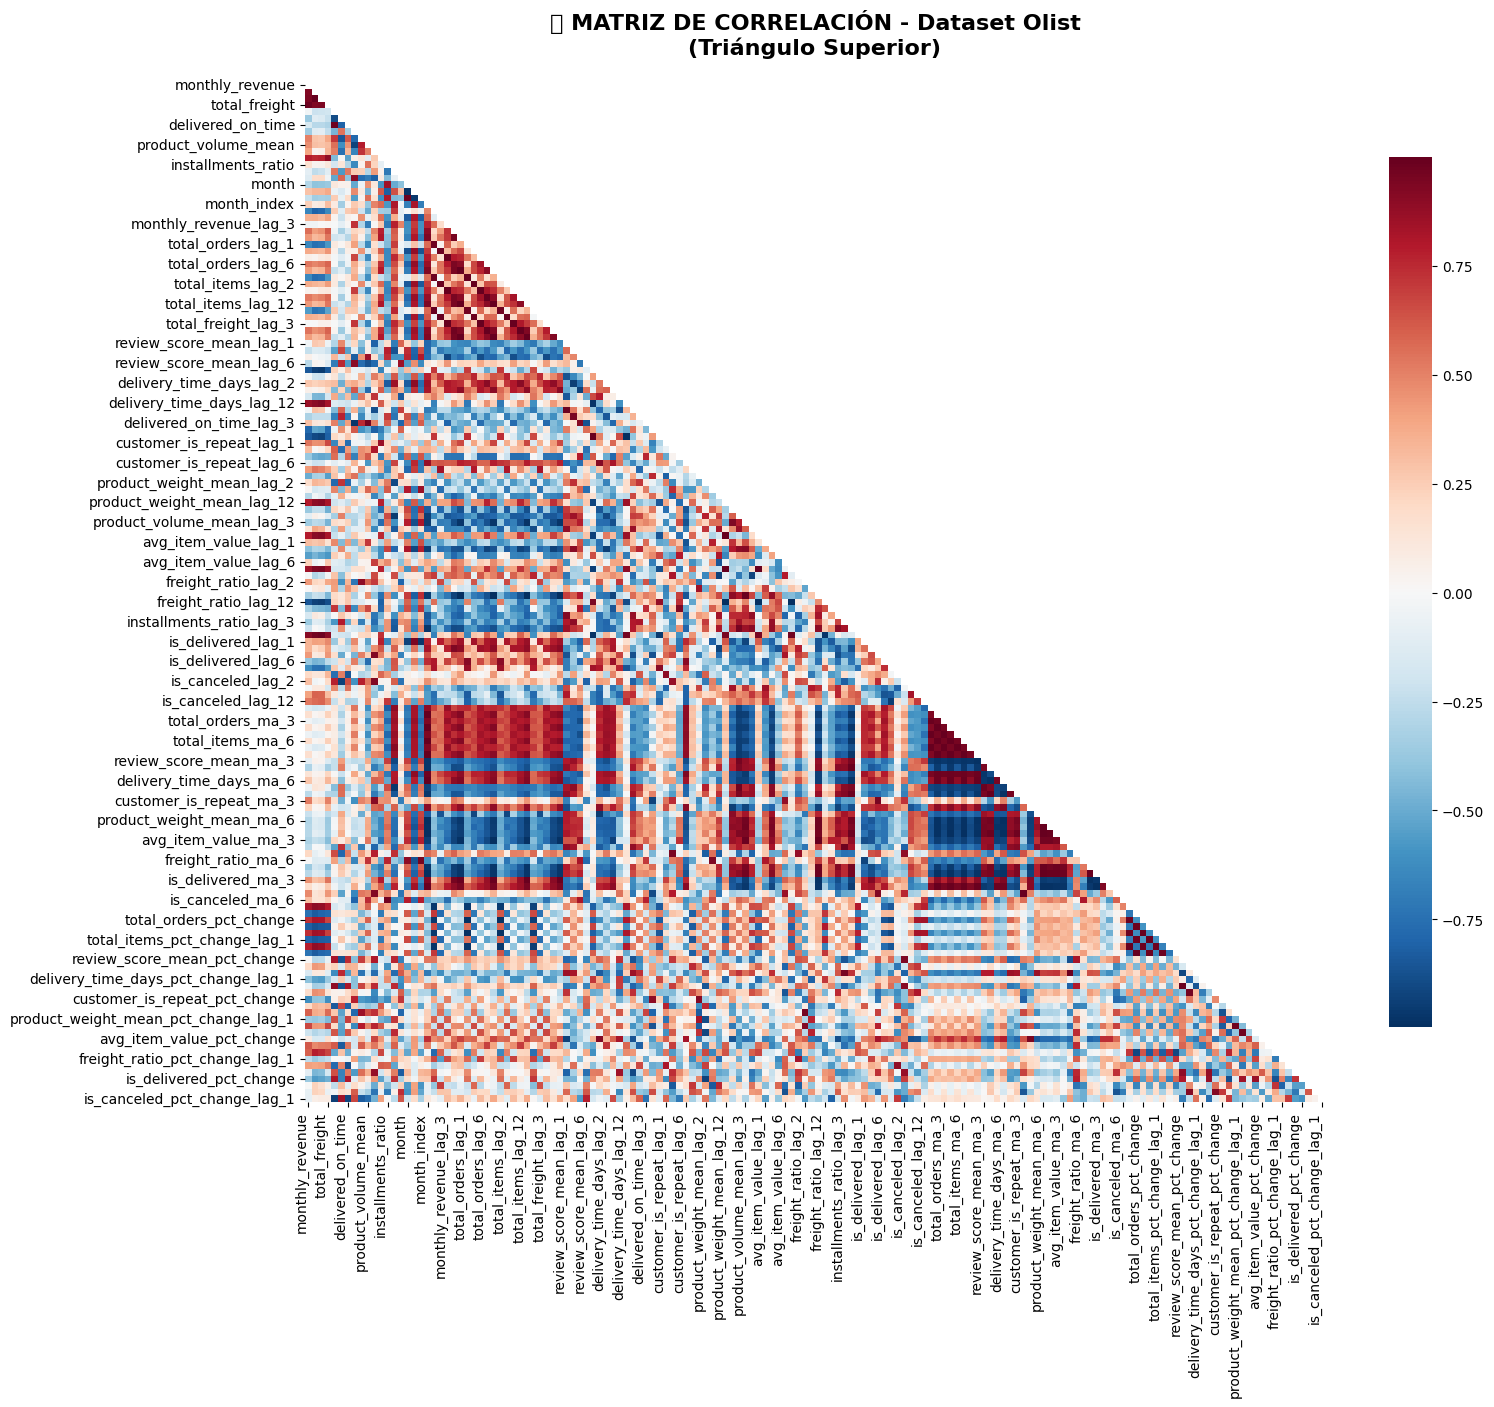


🏆 TOP 20 CORRELACIONES MÁS FUERTES:


,Variable 1,Variable 2,Correlación,Tipo,Fuerza
0,monthly_revenue_ma_6,total_freight_ma_6,0.998967,Positiva,Fuerte
1,total_orders_lag_3,total_items_lag_3,0.998824,Positiva,Fuerte
2,total_orders_pct_change_lag_1,total_items_pct_change_lag_1,0.998732,Positiva,Fuerte
3,total_items_lag_2,total_orders_lag_2,0.998639,Positiva,Fuerte
4,total_freight_lag_3,total_items_lag_3,0.998133,Positiva,Fuerte
5,total_items_lag_1,total_orders_lag_1,0.997990,Positiva,Fuerte
6,total_orders_ma_6,month_index,0.997953,Positiva,Fuerte
7,product_weight_mean_lag_12,product_volume_mean_lag_12,0.997862,Positiva,Fuerte
8,month_index,total_items_ma_6,0.997657,Positiva,Fuerte
9,total_freight_lag_3,monthly_revenue_lag_3,0.997642,Positiva,Fuerte


🔍 Analizando matriz de correlación...
✅ Dataset cargado (Train Split): 6 filas, 155 columnas

📊 Preparando datos para análisis de correlación...
📈 Columnas numéricas para correlación: 154

🧮 Calculando matriz de correlación...


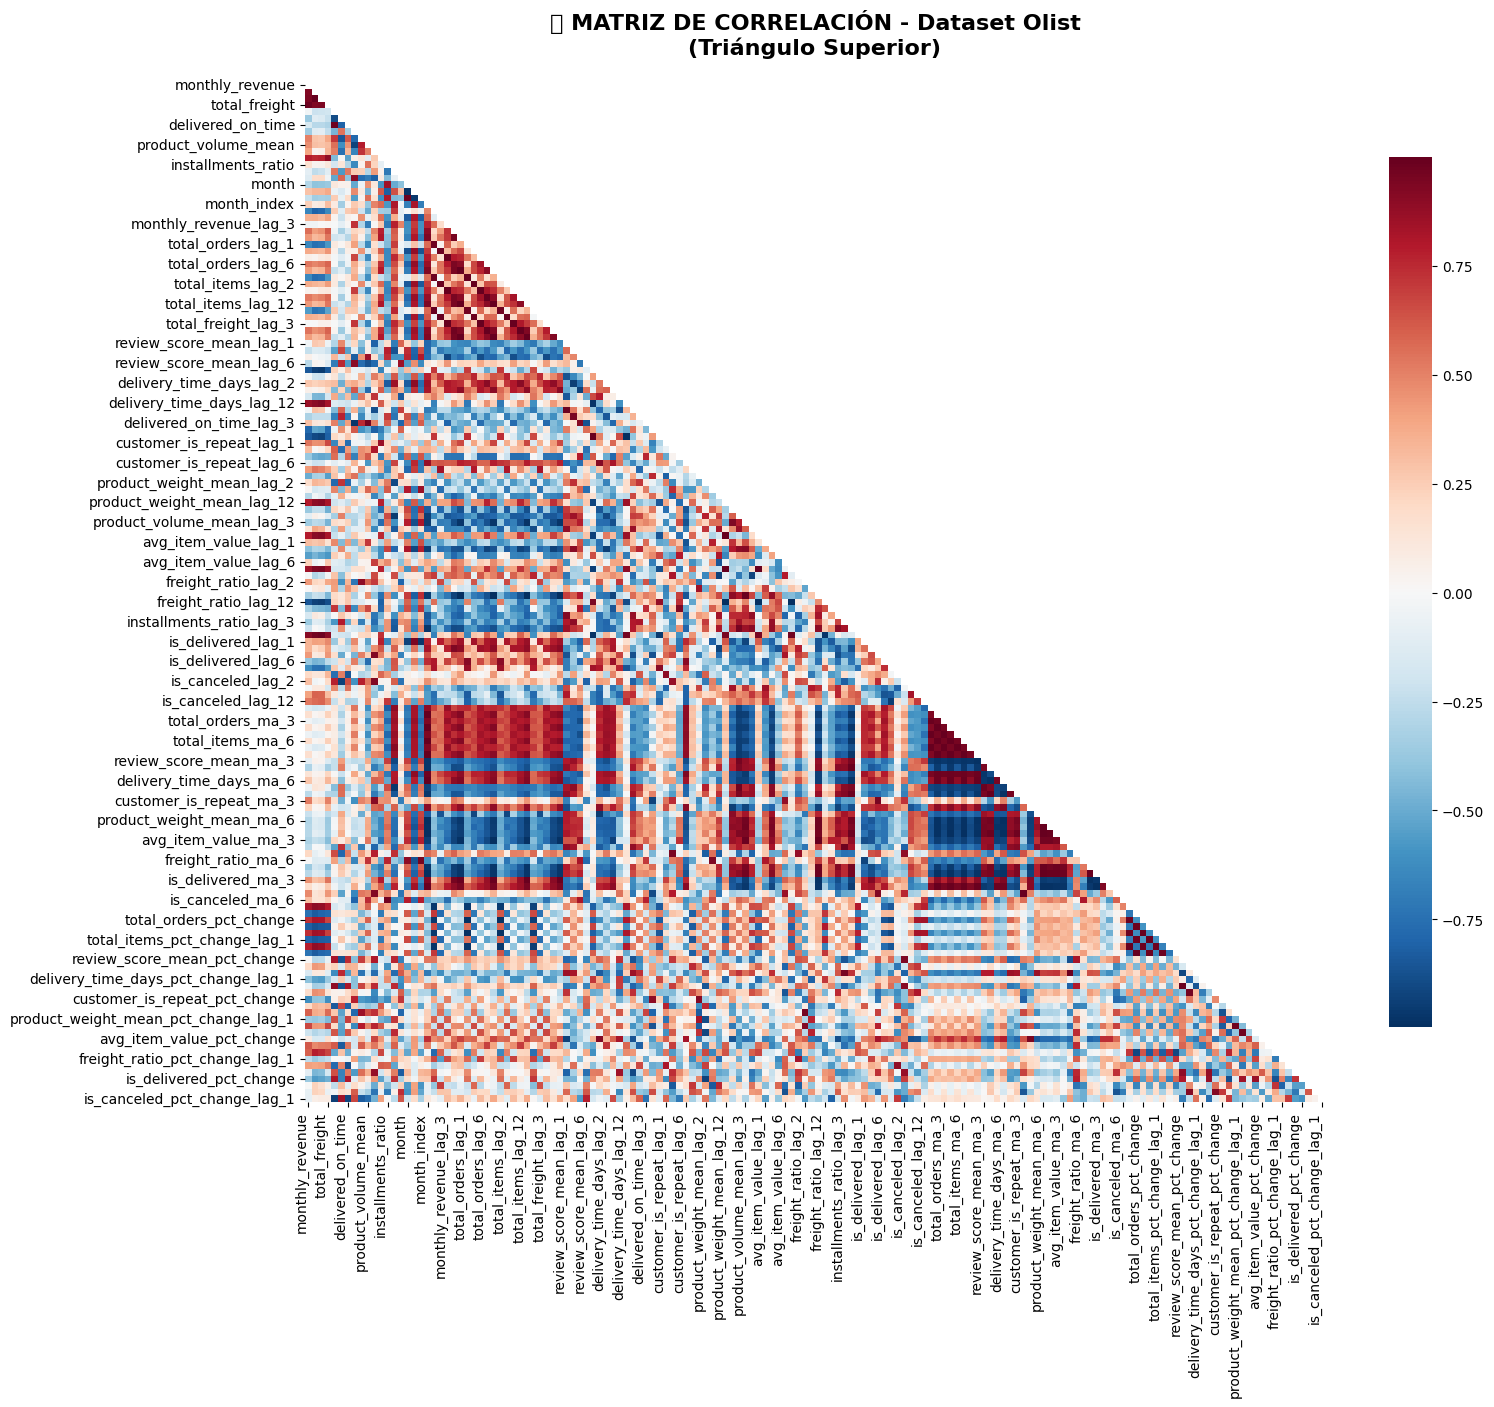


🏆 TOP 20 CORRELACIONES MÁS FUERTES:


,Variable 1,Variable 2,Correlación,Tipo,Fuerza
0,monthly_revenue_ma_6,total_freight_ma_6,0.998967,Positiva,Fuerte
1,total_orders_lag_3,total_items_lag_3,0.998824,Positiva,Fuerte
2,total_orders_pct_change_lag_1,total_items_pct_change_lag_1,0.998732,Positiva,Fuerte
3,total_items_lag_2,total_orders_lag_2,0.998639,Positiva,Fuerte
4,total_freight_lag_3,total_items_lag_3,0.998133,Positiva,Fuerte
5,total_items_lag_1,total_orders_lag_1,0.997990,Positiva,Fuerte
6,total_orders_ma_6,month_index,0.997953,Positiva,Fuerte
7,product_weight_mean_lag_12,product_volume_mean_lag_12,0.997862,Positiva,Fuerte
8,month_index,total_items_ma_6,0.997657,Positiva,Fuerte
9,total_freight_lag_3,monthly_revenue_lag_3,0.997642,Positiva,Fuerte



🎯 CORRELACIONES CON VARIABLES CLAVE DE NEGOCIO:

📋 Correlaciones con 'delivery_time_days':
   is_canceled_lag_2         :  -0.928 (🔴 FUERTE)
   review_score_mean         :  -0.894 (🔴 FUERTE)
   delivered_on_time_pct_change :  -0.872 (🔴 FUERTE)
   review_score_mean_pct_change :  -0.868 (🔴 FUERTE)
   product_weight_mean       :  -0.854 (🔴 FUERTE)

📋 Correlaciones con 'delivered_on_time':
   review_score_mean         :   0.978 (🔴 FUERTE)
   is_canceled_pct_change_lag_1 :  -0.918 (🔴 FUERTE)
   installments_ratio_pct_change :  -0.888 (🔴 FUERTE)
   is_canceled_lag_1         :  -0.854 (🔴 FUERTE)
   delivered_on_time_pct_change :   0.820 (🔴 FUERTE)

📋 Correlaciones con 'is_delivered':
   delivered_on_time_ma_3    :  -0.959 (🔴 FUERTE)
   product_volume_mean_lag_2 :  -0.955 (🔴 FUERTE)
   total_freight_ma_3        :   0.911 (🔴 FUERTE)
   review_score_mean_ma_3    :  -0.905 (🔴 FUERTE)
   product_weight_mean_lag_2 :  -0.901 (🔴 FUERTE)

📋 Correlaciones con 'is_canceled':
   customer_is_repeat      

,Variable 1,Variable 2,Correlación,Tipo,Fuerza
0,monthly_revenue_ma_6,total_freight_ma_6,0.998967,Positiva,Fuerte
1,total_orders_lag_3,total_items_lag_3,0.998824,Positiva,Fuerte
2,total_orders_pct_change_lag_1,total_items_pct_change_lag_1,0.998732,Positiva,Fuerte
3,total_items_lag_2,total_orders_lag_2,0.998639,Positiva,Fuerte
4,total_freight_lag_3,total_items_lag_3,0.998133,Positiva,Fuerte
5,total_items_lag_1,total_orders_lag_1,0.997990,Positiva,Fuerte
6,total_orders_ma_6,month_index,0.997953,Positiva,Fuerte
7,product_weight_mean_lag_12,product_volume_mean_lag_12,0.997862,Positiva,Fuerte
8,month_index,total_items_ma_6,0.997657,Positiva,Fuerte
9,total_freight_lag_3,monthly_revenue_lag_3,0.997642,Positiva,Fuerte


🔍 Analizando matriz de correlación...
✅ Dataset cargado (Train Split): 6 filas, 155 columnas

📊 Preparando datos para análisis de correlación...
📈 Columnas numéricas para correlación: 154

🧮 Calculando matriz de correlación...


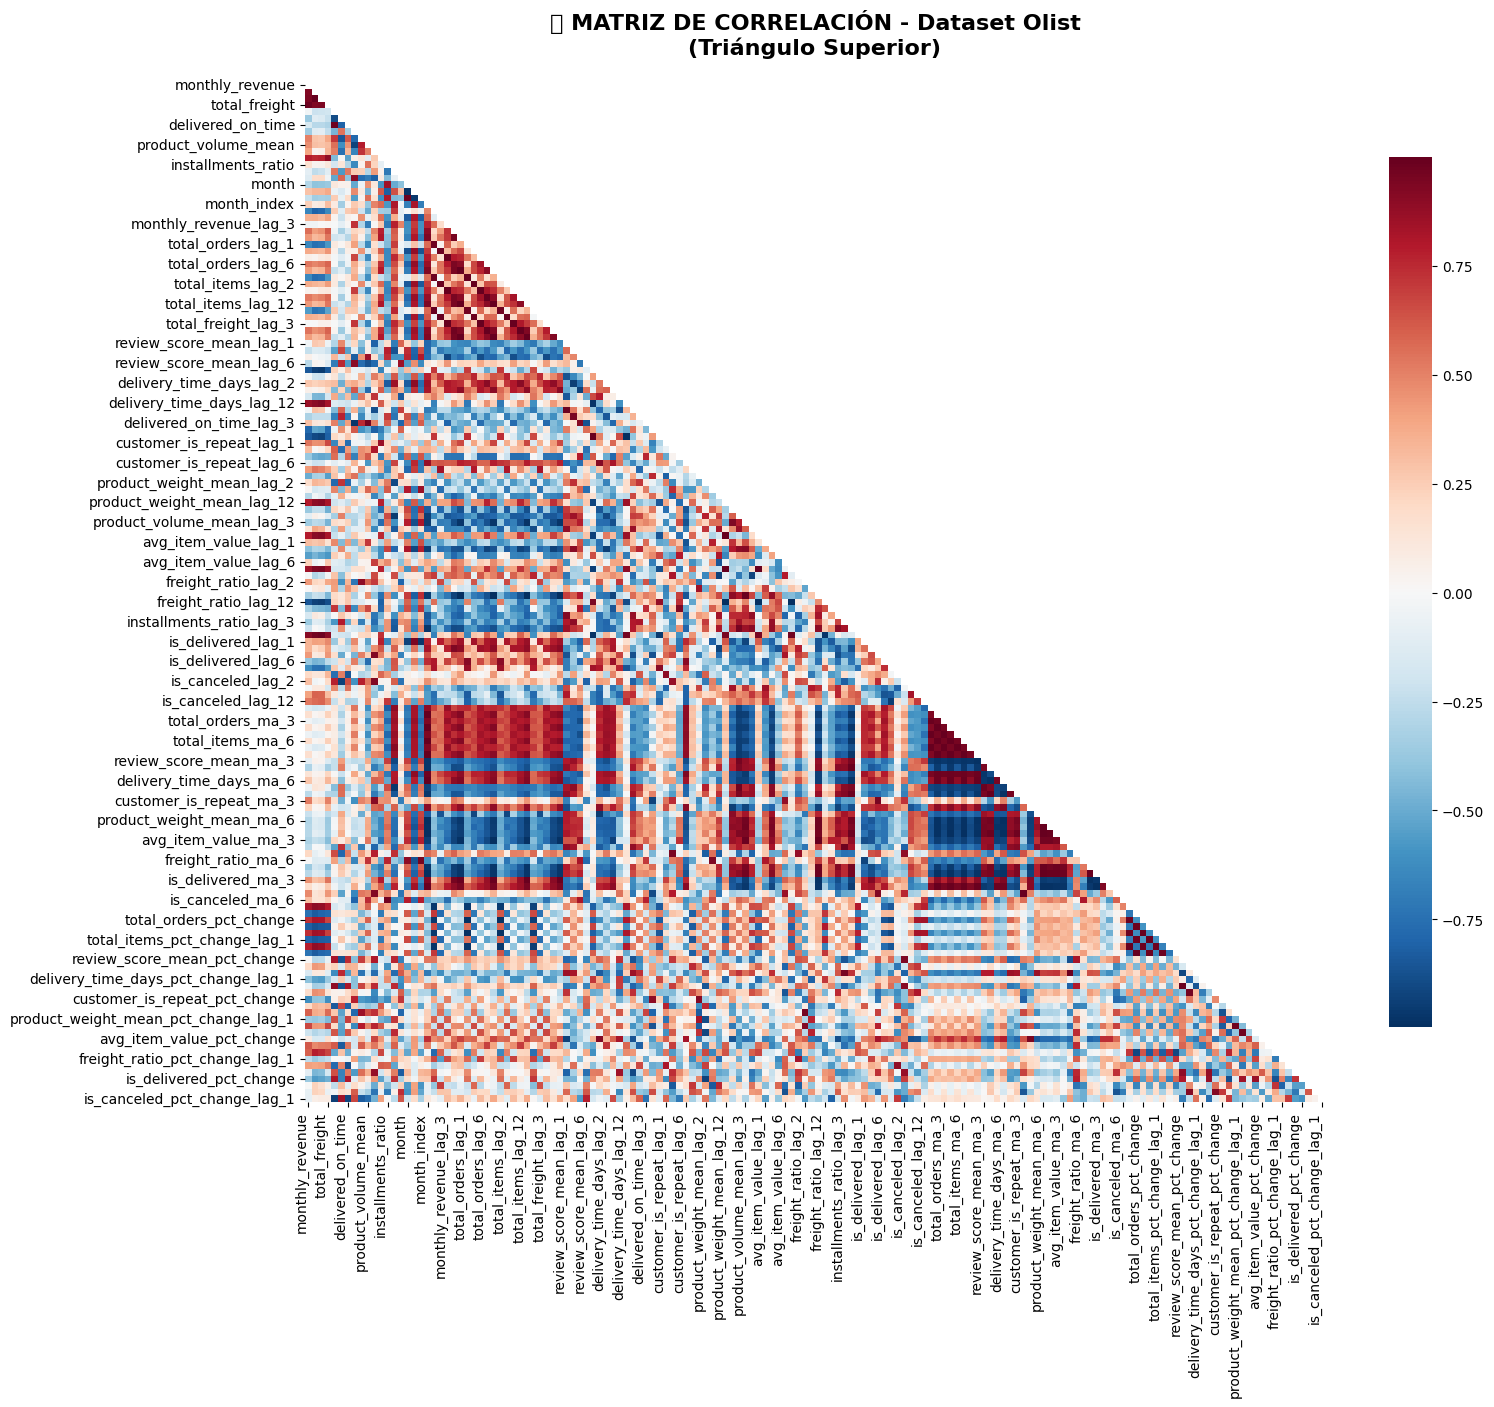


🏆 TOP 20 CORRELACIONES MÁS FUERTES:


,Variable 1,Variable 2,Correlación,Tipo,Fuerza
0,monthly_revenue_ma_6,total_freight_ma_6,0.998967,Positiva,Fuerte
1,total_orders_lag_3,total_items_lag_3,0.998824,Positiva,Fuerte
2,total_orders_pct_change_lag_1,total_items_pct_change_lag_1,0.998732,Positiva,Fuerte
3,total_items_lag_2,total_orders_lag_2,0.998639,Positiva,Fuerte
4,total_freight_lag_3,total_items_lag_3,0.998133,Positiva,Fuerte
5,total_items_lag_1,total_orders_lag_1,0.997990,Positiva,Fuerte
6,total_orders_ma_6,month_index,0.997953,Positiva,Fuerte
7,product_weight_mean_lag_12,product_volume_mean_lag_12,0.997862,Positiva,Fuerte
8,month_index,total_items_ma_6,0.997657,Positiva,Fuerte
9,total_freight_lag_3,monthly_revenue_lag_3,0.997642,Positiva,Fuerte



🎯 CORRELACIONES CON VARIABLES CLAVE DE NEGOCIO:

📋 Correlaciones con 'delivery_time_days':
   is_canceled_lag_2         :  -0.928 (🔴 FUERTE)
   review_score_mean         :  -0.894 (🔴 FUERTE)
   delivered_on_time_pct_change :  -0.872 (🔴 FUERTE)
   review_score_mean_pct_change :  -0.868 (🔴 FUERTE)
   product_weight_mean       :  -0.854 (🔴 FUERTE)

📋 Correlaciones con 'delivered_on_time':
   review_score_mean         :   0.978 (🔴 FUERTE)
   is_canceled_pct_change_lag_1 :  -0.918 (🔴 FUERTE)
   installments_ratio_pct_change :  -0.888 (🔴 FUERTE)
   is_canceled_lag_1         :  -0.854 (🔴 FUERTE)
   delivered_on_time_pct_change :   0.820 (🔴 FUERTE)

📋 Correlaciones con 'is_delivered':
   delivered_on_time_ma_3    :  -0.959 (🔴 FUERTE)
   product_volume_mean_lag_2 :  -0.955 (🔴 FUERTE)
   total_freight_ma_3        :   0.911 (🔴 FUERTE)
   review_score_mean_ma_3    :  -0.905 (🔴 FUERTE)
   product_weight_mean_lag_2 :  -0.901 (🔴 FUERTE)

📋 Correlaciones con 'is_canceled':
   customer_is_repeat      

,Variable 1,Variable 2,Correlación,Tipo,Fuerza
0,monthly_revenue_ma_6,total_freight_ma_6,0.998967,Positiva,Fuerte
1,total_orders_lag_3,total_items_lag_3,0.998824,Positiva,Fuerte
2,total_orders_pct_change_lag_1,total_items_pct_change_lag_1,0.998732,Positiva,Fuerte
3,total_items_lag_2,total_orders_lag_2,0.998639,Positiva,Fuerte
4,total_freight_lag_3,total_items_lag_3,0.998133,Positiva,Fuerte
5,total_items_lag_1,total_orders_lag_1,0.997990,Positiva,Fuerte
6,total_orders_ma_6,month_index,0.997953,Positiva,Fuerte
7,product_weight_mean_lag_12,product_volume_mean_lag_12,0.997862,Positiva,Fuerte
8,month_index,total_items_ma_6,0.997657,Positiva,Fuerte
9,total_freight_lag_3,monthly_revenue_lag_3,0.997642,Positiva,Fuerte



💾 Matriz de correlación guardada como: 'matriz_correlacion_olist.csv'


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
plt.style.use('default')
sns.set_palette("husl")
print("🔍 Analizando matriz de correlación...")

# Adaptación para usar el dataframe en memoria 'train_clean'
if 'train_clean' in locals():
    df = train_clean.copy()
    print(f"✅ Dataset cargado (Train Split): {df.shape[0]} filas, {df.shape[1]} columnas")
else:
    print("❌ No se encontró 'train_clean'. Asegúrate de ejecutar las celdas anteriores.")
    df = pd.DataFrame()

# 1. PREPARACIÓN DE DATOS PARA CORRELACIÓN
print("\n📊 Preparando datos para análisis de correlación...")

# Seleccionar solo columnas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Excluir columnas binarias si se desea (opcional)
binary_columns = ['is_delivered', 'is_canceled', 'delivered_on_time']
cols_to_exclude = [col for col in binary_columns if col in numeric_df.columns and df[col].nunique() <= 2]
numeric_df = numeric_df.drop(columns=cols_to_exclude)

print(f"📈 Columnas numéricas para correlación: {len(numeric_df.columns)}")

# 2. MATRIZ DE CORRELACIÓN BÁSICA
print("\n🧮 Calculando matriz de correlación...")
correlation_matrix = numeric_df.corr()

# 3. VISUALIZACIÓN 1: MATRIZ DE CORRELACIÓN CON HEATMAP
plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Ajustar anotaciones según cantidad de variables
show_annot = True if len(numeric_df.columns) <= 20 else False

heatmap = sns.heatmap(correlation_matrix,
                      mask=mask,
                      annot=show_annot,
                      fmt=".2f",
                      cmap="RdBu_r",
                      center=0,
                      square=True,
                      cbar_kws={"shrink": .8},
                      annot_kws={"size": 10})

plt.title('🔗 MATRIZ DE CORRELACIÓN - Dataset Olist\n(Triángulo Superior)',
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=90, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 5. CORRELACIONES MÁS FUERTES (TOP 20)
print("\n🏆 TOP 20 CORRELACIONES MÁS FUERTES:")

corr_pairs = correlation_matrix.unstack().sort_values(ascending=False, key=abs)
corr_pairs = corr_pairs[corr_pairs < 0.999]

top_correlations = []
seen_pairs = set()
for idx, (pair, value) in enumerate(corr_pairs.items()):
    if len(top_correlations) >= 20:
        break
    p1, p2 = pair
    if p1 == p2: continue
    sorted_pair = tuple(sorted([p1, p2]))
    if sorted_pair in seen_pairs: continue
    
    seen_pairs.add(sorted_pair)
    top_correlations.append({
        'Variable 1': p1,
        'Variable 2': p2,
        'Correlación': value,
        'Tipo': 'Positiva' if value > 0 else 'Negativa',
        'Fuerza': 'Fuerte' if abs(value) > 0.7 else
                 'Moderada' if abs(value) > 0.3 else 'Débil'
    })

top_corr_df = pd.DataFrame(top_correlations)
display(top_corr_df)

# 6. CORRELACIONES CON VARIABLES CLAVE DE NEGOCIO
print("\n🎯 CORRELACIONES CON VARIABLES CLAVE DE NEGOCIO:")

# Mapeo de nombres si es necesario (ajustado a lo que tenemos en preprocess.py)
key_variables = ['delivery_time_days', 'gross_sales_amount', 'delivered_on_time',
                 'is_delivered', 'is_canceled', 'freight_ratio', 'monthly_revenue']

for key_var in key_variables:
    if key_var in correlation_matrix.columns:
        print(f"\n📋 Correlaciones con '{key_var}':")
        corrs_with_key = correlation_matrix[key_var].sort_values(ascending=False, key=abs)
        corrs_with_key = corrs_with_key[corrs_with_key.index != key_var]
        for var, corr in corrs_with_key.head(5).items():
            strength = "🔴 FUERTE" if abs(corr) > 0.7 else "🟡 MODERADA" if abs(corr) > 0.3 else "🟢 DÉBIL"
            print(f"   {var:25} : {corr:7.3f} ({strength})")

# 9. ANÁLISIS DE MULTICOLINEALIDAD
print("\n⚠️  ANÁLISIS DE MULTICOLINEALIDAD (Pares > 0.8):")
high_corr_pairs = [item for item in top_correlations if abs(item['Correlación']) > 0.8]

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs)
    display(high_corr_df)
else:
    print("✅ No se detectaron pares con correlación muy alta (>0.8) en el top 20.")

# 11. GUARDAR MATRIZ DE CORRELACIÓN
correlation_matrix.to_csv('matriz_correlacion_olist.csv')
print(f"\n💾 Matriz de correlación guardada como: 'matriz_correlacion_olist.csv'")

## 7. Simulación Mensual
Simulamos que estamos en Julio 2018 y queremos predecir Agosto 2018.

In [30]:
# Simulación: Datos hasta 2018-07, predecir 2018-08
pred_august = run_monthly_pipeline(data, "2018-07", "2018-08")

# Valor real (solo para comparar, en la vida real no lo tendríamos)
real_august = final_test[target_col].values[0]
print(f"Valor Real Agosto 2018: R$ {real_august:,.2f}")
print(f"Error: R$ {pred_august - real_august:,.2f}")

--- Running Pipeline Simulation ---
Current Date (Simulated): End of 2018-07
Goal: Predict Revenue for 2018-08
Model trained on available history.
Predicted Revenue for 2018-08: R$ 290,142.28
Valor Real Agosto 2018: R$ 1,022,361.43
Error: R$ -732,219.15
Model trained on available history.
Predicted Revenue for 2018-08: R$ 290,142.28
Valor Real Agosto 2018: R$ 1,022,361.43
Error: R$ -732,219.15


/Users/angrysp/Documents/sergioMaestria/m13/MIADAS13/src/features.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_ma_{window}"] = df[col].shift(1).rolling(window=window).mean()
/Users/angrysp/Documents/sergioMaestria/m13/MIADAS13/src/features.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{col}_ma_{window}"] = df[col].shift(1).rolling(window=window).mean()
/Users/angrysp/Documents/sergioMaestria/m13/MIADAS13/src/features.py:35: PerformanceWarning: DataFrame is highly fragmented.  This is usually the re

## 1. Importar Librerías y Cargar Datos


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from IPython.display import display

In [32]:
from pathlib import Path

customers = pd.read_csv("https://raw.githubusercontent.com/paukiss/MIADAS13/refs/heads/main/data/dataset/olist_customers_dataset.csv")
items =  pd.read_csv("https://raw.githubusercontent.com/paukiss/MIADAS13/refs/heads/main/data/dataset/olist_order_items_dataset.csv")
payments =  pd.read_csv("https://raw.githubusercontent.com/paukiss/MIADAS13/refs/heads/main/data/dataset/olist_order_payments_dataset.csv")
reviews = pd.read_csv("https://raw.githubusercontent.com/paukiss/MIADAS13/refs/heads/main/data/dataset/olist_order_reviews_dataset.csv")
orders = pd.read_csv("https://raw.githubusercontent.com/paukiss/MIADAS13/refs/heads/main/data/dataset/olist_orders_dataset.csv")
products = pd.read_csv("https://raw.githubusercontent.com/paukiss/MIADAS13/refs/heads/main/data/dataset/olist_products_dataset.csv")
sellers = pd.read_csv("https://raw.githubusercontent.com/paukiss/MIADAS13/refs/heads/main/data/dataset/olist_sellers_dataset.csv")
translation = pd.read_csv("https://raw.githubusercontent.com/paukiss/MIADAS13/refs/heads/main/data/dataset/product_category_name_translation.csv")
geolocation = pd.read_csv("https://raw.githubusercontent.com/paukiss/MIADAS13/refs/heads/main/data/dataset/olist_geolocation_dataset.csv")

datasets_dict = {
    'orders': orders,
    'payments': payments,
    'items': items,
    'customers': customers,
    'products': products,
    'sellers': sellers,
    'reviews': reviews,
    'translation': translation
}

metadata_rows = []
for name, df_tmp in datasets_dict.items():
    for col in df_tmp.columns:
        metadata_rows.append({
            'dataset': name,
            'column': col,
            'dtype': str(df_tmp[col].dtype)
        })

metadata_catalog = pd.DataFrame(metadata_rows)
unique_columns = metadata_catalog['column'].nunique()
total_metadata = metadata_catalog.shape[0]
print(f"Metadatos totales (dataset, columna): {total_metadata}")
print(f"Columnas únicas disponibles en el ecosistema Olist: {unique_columns}")
print("Ejemplo de metadatos:")
metadata_catalog.head(15)

Metadatos totales (dataset, columna): 47
Columnas únicas disponibles en el ecosistema Olist: 40
Ejemplo de metadatos:


,dataset,column,dtype
0,orders,order_id,object
1,orders,customer_id,object
2,orders,order_status,object
3,orders,order_purchase_timestamp,object
4,orders,order_approved_at,object
5,orders,order_delivered_carrier_date,object
6,orders,order_delivered_customer_date,object
7,orders,order_estimated_delivery_date,object
8,payments,order_id,object
9,payments,payment_sequential,int64


In [33]:
# @title
def mode_or_nan(series: pd.Series):
    mode_vals = series.mode(dropna=True)
    return mode_vals.iloc[0] if not mode_vals.empty else np.nan


def mean_length(series: pd.Series):
    non_null = series.dropna().astype(str)
    lengths = non_null.map(len)
    return lengths.mean() if not lengths.empty else np.nan


def build_master_table(reference_month: str | None = None, save: bool = False, output_dir: Path = Path('data/interim')) -> pd.DataFrame:
    """Genera la tabla maestra con 60+ features para modelado y métricas de negocio."""
    output_dir = Path(output_dir)

    orders_tmp = orders.copy()
    payments_tmp = payments.copy()
    items_tmp = items.copy()
    customers_tmp = customers.copy()
    products_tmp = products.copy()
    sellers_tmp = sellers.copy()
    reviews_tmp = reviews.copy()
    translation_tmp = translation.copy()

    items_tmp['shipping_limit_date'] = pd.to_datetime(items_tmp['shipping_limit_date'], errors='coerce')
    reviews_tmp['review_creation_date'] = pd.to_datetime(reviews_tmp['review_creation_date'], errors='coerce')
    reviews_tmp['review_answer_timestamp'] = pd.to_datetime(reviews_tmp.get('review_answer_timestamp'), errors='coerce')

    payments_agg = (
        payments_tmp.groupby('order_id').agg(
            payment_total=pd.NamedAgg(column='payment_value', aggfunc='sum'),
            payment_mean=pd.NamedAgg(column='payment_value', aggfunc='mean'),
            payment_median=pd.NamedAgg(column='payment_value', aggfunc='median'),
            payment_installments_max=pd.NamedAgg(column='payment_installments', aggfunc='max'),
            payment_installments_mean=pd.NamedAgg(column='payment_installments', aggfunc='mean'),
            payment_types=pd.NamedAgg(column='payment_type', aggfunc=lambda x: ','.join(sorted(set(x)))),
            primary_payment_type=pd.NamedAgg(column='payment_type', aggfunc=mode_or_nan),
            payments_count=pd.NamedAgg(column='payment_sequential', aggfunc='count')
        ).reset_index()
    )

    items_agg = (
        items_tmp.groupby('order_id').agg(
            total_items=pd.NamedAgg(column='order_item_id', aggfunc='count'),
            distinct_products=pd.NamedAgg(column='product_id', aggfunc=pd.Series.nunique),
            distinct_sellers=pd.NamedAgg(column='seller_id', aggfunc=pd.Series.nunique),
            total_price=pd.NamedAgg(column='price', aggfunc='sum'),
            avg_price=pd.NamedAgg(column='price', aggfunc='mean'),
            max_price=pd.NamedAgg(column='price', aggfunc='max'),
            min_price=pd.NamedAgg(column='price', aggfunc='min'),
            total_freight=pd.NamedAgg(column='freight_value', aggfunc='sum'),
            avg_freight=pd.NamedAgg(column='freight_value', aggfunc='mean'),
            shipping_limit_max=pd.NamedAgg(column='shipping_limit_date', aggfunc='max'),
            shipping_limit_min=pd.NamedAgg(column='shipping_limit_date', aggfunc='min')
        ).reset_index()
    )

    items_products = items_tmp.merge(products_tmp, on='product_id', how='left')
    items_products = items_products.merge(translation_tmp, on='product_category_name', how='left')
    items_products['product_volume_cm3'] = (
        items_products['product_length_cm'] *
        items_products['product_height_cm'] *
        items_products['product_width_cm']
    )

    product_agg = (
        items_products.groupby('order_id').agg(
            top_category_pt=pd.NamedAgg(column='product_category_name', aggfunc=mode_or_nan),
            top_category_en=pd.NamedAgg(column='product_category_name_english', aggfunc=mode_or_nan),
            product_weight_sum=pd.NamedAgg(column='product_weight_g', aggfunc='sum'),
            product_weight_mean=pd.NamedAgg(column='product_weight_g', aggfunc='mean'),
            product_length_mean=pd.NamedAgg(column='product_length_cm', aggfunc='mean'),
            product_height_mean=pd.NamedAgg(column='product_height_cm', aggfunc='mean'),
            product_width_mean=pd.NamedAgg(column='product_width_cm', aggfunc='mean'),
            product_volume_sum=pd.NamedAgg(column='product_volume_cm3', aggfunc='sum'),
            product_volume_mean=pd.NamedAgg(column='product_volume_cm3', aggfunc='mean')
        ).reset_index()
    )

    items_sellers = items_tmp.merge(sellers_tmp, on='seller_id', how='left')
    seller_agg = (
        items_sellers.groupby('order_id').agg(
            seller_state_mode=pd.NamedAgg(column='seller_state', aggfunc=mode_or_nan),
            seller_city_mode=pd.NamedAgg(column='seller_city', aggfunc=mode_or_nan),
            seller_count=pd.NamedAgg(column='seller_id', aggfunc=pd.Series.nunique)
        ).reset_index()
    )

    reviews_agg = (
        reviews_tmp.groupby('order_id').agg(
            review_score_mean=pd.NamedAgg(column='review_score', aggfunc='mean'),
            review_score_std=pd.NamedAgg(column='review_score', aggfunc='std'),
            review_count=pd.NamedAgg(column='review_id', aggfunc='count'),
            review_comment_count=pd.NamedAgg(column='review_comment_message', aggfunc=lambda x: x.notna().sum()),
            review_comment_avg_len=pd.NamedAgg(column='review_comment_message', aggfunc=mean_length),
            review_latest_score=pd.NamedAgg(column='review_score', aggfunc='last'),
            review_latest_date=pd.NamedAgg(column='review_creation_date', aggfunc='max'),
            review_response_rate=pd.NamedAgg(column='review_answer_timestamp', aggfunc=lambda x: x.notna().mean())
        ).reset_index()
    )

    master = (orders_tmp
              .merge(customers_tmp, on='customer_id', how='left')
              .merge(payments_agg, on='order_id', how='left')
              .merge(items_agg, on='order_id', how='left')
              .merge(product_agg, on='order_id', how='left')
              .merge(seller_agg, on='order_id', how='left')
              .merge(reviews_agg, on='order_id', how='left'))

    master['order_purchase_timestamp'] = pd.to_datetime(master['order_purchase_timestamp'], errors='coerce')
    master['order_approved_at'] = pd.to_datetime(master['order_approved_at'], errors='coerce')
    master['order_delivered_carrier_date'] = pd.to_datetime(master['order_delivered_carrier_date'], errors='coerce')
    master['order_delivered_customer_date'] = pd.to_datetime(master['order_delivered_customer_date'], errors='coerce')
    master['order_estimated_delivery_date'] = pd.to_datetime(master['order_estimated_delivery_date'], errors='coerce')

    master = master.sort_values(['customer_unique_id', 'order_purchase_timestamp'])
    master['customer_order_number'] = master.groupby('customer_unique_id').cumcount() + 1
    master['customer_is_repeat'] = (master['customer_order_number'] > 1).astype(int)
    master['days_since_prev_purchase'] = master.groupby('customer_unique_id')['order_purchase_timestamp'].diff().dt.days
    master['days_since_first_purchase'] = (
        master['order_purchase_timestamp'] -
        master.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min')
    ).dt.days

    master['delivery_time_days'] = (
        master['order_delivered_customer_date'] - master['order_purchase_timestamp']
    ).dt.days
    master['approval_lag_hours'] = (
        master['order_approved_at'] - master['order_purchase_timestamp']
    ).dt.total_seconds() / 3600
    master['carrier_lag_hours'] = (
        master['order_delivered_carrier_date'] - master['order_approved_at']
    ).dt.total_seconds() / 3600
    master['delivery_delay_vs_estimate'] = (
        master['order_delivered_customer_date'] - master['order_estimated_delivery_date']
    ).dt.days
    master['delivered_on_time'] = (master['delivery_delay_vs_estimate'] <= 0).astype(int)

    master['order_month'] = master['order_purchase_timestamp'].dt.to_period('M').astype(str)
    master['order_week'] = master['order_purchase_timestamp'].dt.to_period('W').astype(str)
    master['weekday_purchase'] = master['order_purchase_timestamp'].dt.dayofweek
    master['hour_purchase'] = master['order_purchase_timestamp'].dt.hour

    master['avg_item_value'] = master['total_price'] / master['total_items']
    master['freight_ratio'] = master['total_freight'] / master['total_price']
    master['installments_ratio'] = master['payment_installments_mean'] / master['payments_count'].replace({0: np.nan})
    master['contribution_margin_proxy'] = master['total_price'] - master['total_freight']
    master.replace([np.inf, -np.inf], np.nan, inplace=True)

    master['is_delivered'] = (master['order_status'] == 'delivered').astype(int)
    master['is_canceled'] = (master['order_status'] == 'canceled').astype(int)

    if reference_month is not None:
        period = pd.Period(reference_month, freq='M')
        mask = master['order_month'] == str(period)
        master_filtered = master.loc[mask].copy()
    else:
        master_filtered = master.copy()
        period = master_filtered['order_month'].max()

    if save:
        output_dir.mkdir(parents=True, exist_ok=True)
        file_path = output_dir / f"master_table_{str(period).replace('/', '-')}.csv"
        master_filtered.to_csv(file_path, index=False)
        print(f"Tabla maestra guardada en: {file_path}")

    print(f"Tabla maestra generada: {master_filtered.shape[0]} registros y {master_filtered.shape[1]} columnas")
    return master_filtered


master_table = build_master_table()
last_month_period = master_table['order_month'].max()
monthly_master_snapshot = build_master_table(reference_month=last_month_period, save=True)

print(f"Último mes disponible: {last_month_period}")
monthly_master_snapshot.head()

Tabla maestra generada: 99441 registros y 70 columnas
Tabla maestra guardada en: data/interim/master_table_2018-10.csv
Tabla maestra generada: 4 registros y 70 columnas
Último mes disponible: 2018-10
Tabla maestra guardada en: data/interim/master_table_2018-10.csv
Tabla maestra generada: 4 registros y 70 columnas
Último mes disponible: 2018-10


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,order_month,order_week,weekday_purchase,hour_purchase,avg_item_value,freight_ratio,installments_ratio,contribution_margin_proxy,is_delivered,is_canceled
68373,b059ee4de278302d550a3035c4cdb740,856336203359aa6a61bf3826f7d84c49,canceled,2018-10-16 20:16:02,NaT,NaT,NaT,2018-11-12,262e1f1e26e92e86375f86840b4ffd63,64600,...,2018-10,2018-10-15/2018-10-21,1,20,NaN,NaN,1.0,NaN,0,1
88500,616fa7d4871b87832197b2a137a115d2,bf6181a85bbb4115736c0a8db1a53be3,canceled,2018-10-01 15:30:09,NaT,NaT,NaT,2018-10-23,634420a0ea42302205032ed44ac7fccc,27175,...,2018-10,2018-10-01/2018-10-07,0,15,NaN,NaN,1.0,NaN,0,1
60938,10a045cdf6a5650c21e9cfeb60384c16,a4b417188addbc05b26b72d5e44837a1,canceled,2018-10-17 17:30:18,NaT,NaT,NaT,2018-10-30,87ab9fec999db8bd5774917de3cdf01c,18077,...,2018-10,2018-10-15/2018-10-21,2,17,NaN,NaN,1.0,NaN,0,1
31891,a2ac6dad85cf8af5b0afb510a240fe8c,4c2ec60c29d10c34bd49cb88aa85cfc4,canceled,2018-10-03 18:55:29,NaT,NaT,NaT,2018-10-16,af5454198a97379394cacf676e1e96cb,11900,...,2018-10,2018-10-01/2018-10-07,2,18,NaN,NaN,1.0,NaN,0,1


**Reduccion de la MASTER TABLE**


Construyendo tabla con features seleccionados...
✓ Tabla guardada en: data/interim/selected_features_table.csv
✓ Tabla final generada: 99441 registros y 30 columnas

ANÁLISIS EXPLORATORIO DE LA TABLA FINAL
📊 Dimensiones de la tabla: (99441, 30)
📅 Rango temporal: 2016-09 a 2018-10

📈 Estadísticas descriptivas de variables numéricas:
       payments_count   total_items  distinct_products  distinct_sellers  \
count    99440.000000  98666.000000       98666.000000      98666.000000   
mean         1.044710      1.141731           1.038098          1.013622   
std          0.381166      0.538452           0.226456          0.122297   
min          1.000000      1.000000           1.000000          1.000000   
25%          1.000000      1.000000           1.000000          1.000000   
50%          1.000000      1.000000           1.000000          1.000000   
75%          1.000000      1.000000           1.000000          1.000000   
max         29.000000     21.000000           8.000000   

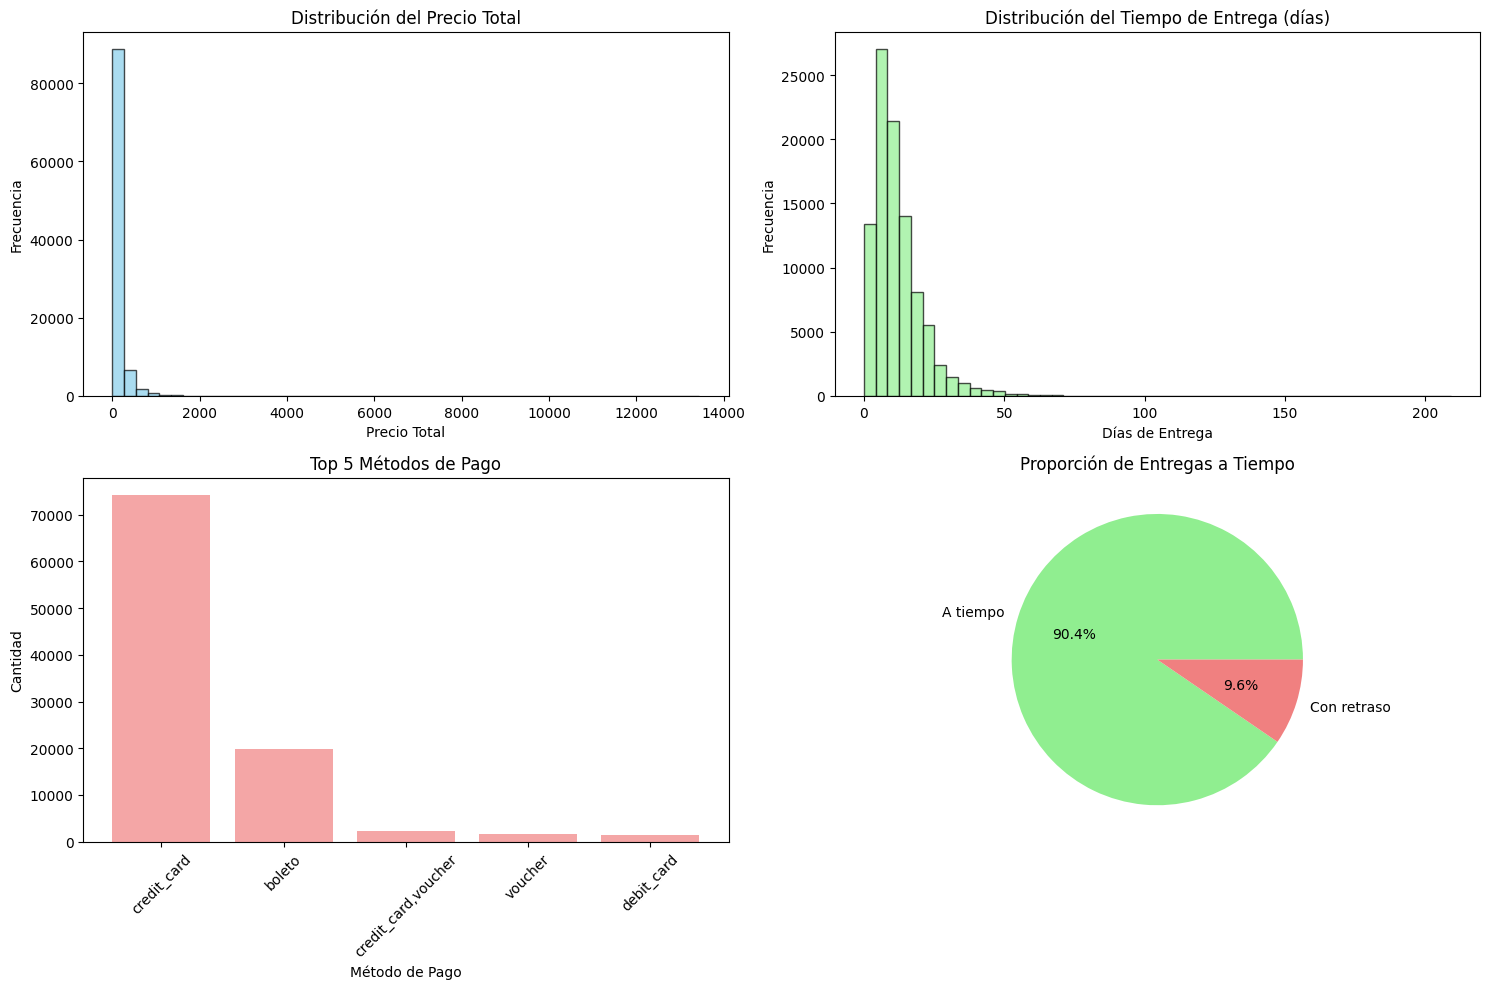


💾 Guardando dataset final...
✓ Dataset guardado como: olist_selected_features_clean.csv

RESUMEN FINAL DEL PROCESO
✅ Columnas seleccionadas: 30
✅ Registros procesados: 99,441
✅ Período cubierto: 2016-09 a 2018-10
✅ Tasa de entrega: 97.0%
✅ Tasa de cancelación: 0.6%

👀 Vista previa de los datos:
✓ Dataset guardado como: olist_selected_features_clean.csv

RESUMEN FINAL DEL PROCESO
✅ Columnas seleccionadas: 30
✅ Registros procesados: 99,441
✅ Período cubierto: 2016-09 a 2018-10
✅ Tasa de entrega: 97.0%
✅ Tasa de cancelación: 0.6%

👀 Vista previa de los datos:


,order_id,customer_id,order_purchase_timestamp,customer_city,customer_state,payment_types,payments_count,total_items,distinct_products,distinct_sellers,...,carrier_lag_hours,delivery_delay_vs_estimate,delivered_on_time,order_month,order_week,weekday_purchase,hour_purchase,freight_ratio,is_delivered,is_canceled
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,sao paulo,SP,"credit_card,voucher",3.0,1.0,1.0,1.0,...,56.795833,-8.0,1,2017-10,2017-10-02/2017-10-08,0,10,0.290764,1,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,barreiras,BA,boleto,1.0,1.0,1.0,1.0,...,11.109167,-6.0,1,2018-07,2018-07-23/2018-07-29,1,20,0.191744,1,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,vianopolis,GO,credit_card,1.0,1.0,1.0,1.0,...,4.910278,-18.0,1,2018-08,2018-08-06/2018-08-12,2,8,0.120200,1,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,sao goncalo do amarante,RN,credit_card,1.0,1.0,1.0,1.0,...,89.900000,-13.0,1,2017-11,2017-11-13/2017-11-19,5,19,0.604444,1,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,santo andre,SP,credit_card,1.0,1.0,1.0,1.0,...,21.434722,-10.0,1,2018-02,2018-02-12/2018-02-18,1,21,0.438191,1,0
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,2017-07-09 21:57:05,congonhinhas,PR,credit_card,1.0,1.0,1.0,1.0,...,40.797500,-6.0,1,2017-07,2017-07-03/2017-07-09,6,21,0.184990,1,0
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,2017-04-11 12:22:08,santa rosa,RS,credit_card,1.0,1.0,1.0,1.0,...,NaN,NaN,0,2017-04,2017-04-10/2017-04-16,1,12,0.321643,0,0
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,2017-05-16 13:10:30,nilopolis,RJ,credit_card,1.0,1.0,1.0,1.0,...,140.759722,-12.0,1,2017-05,2017-05-15/2017-05-21,1,13,0.252875,1,0
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,2017-01-23 18:29:09,faxinalzinho,RS,boleto,1.0,1.0,1.0,1.0,...,35.428889,-32.0,1,2017-01,2017-01-23/2017-01-29,0,18,0.806533,1,0
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,2017-07-29 11:55:02,sorocaba,SP,"credit_card,voucher",2.0,1.0,1.0,1.0,...,295.664444,-7.0,1,2017-07,2017-07-24/2017-07-30,5,11,0.131809,1,0



🎯 ¡Proceso completado exitosamente!


In [34]:
# 2. FUNCIÓN AUXILIAR PARA MODO
def mode_or_nan(series: pd.Series):
    mode_vals = series.mode(dropna=True)
    return mode_vals.iloc[0] if not mode_vals.empty else np.nan

# 3. CONSTRUCCIÓN DE LA TABLA MASTER SIMPLIFICADA
def build_selected_features_table(save: bool = False, output_dir: Path = Path('data/interim')) -> pd.DataFrame:
    """
    Construye una tabla con las columnas seleccionadas específicamente
    """
    # Crear copias para no modificar los originales
    orders_tmp = orders.copy()
    payments_tmp = payments.copy()
    items_tmp = items.copy()
    customers_tmp = customers.copy()
    products_tmp = products.copy()
    sellers_tmp = sellers.copy()
    reviews_tmp = reviews.copy()
    translation_tmp = translation.copy()

    # Convertir fechas
    items_tmp['shipping_limit_date'] = pd.to_datetime(items_tmp['shipping_limit_date'], errors='coerce')

    # AGRUPACIÓN DE PAYMENTS
    payments_agg = (
        payments_tmp.groupby('order_id').agg(
            payment_types=pd.NamedAgg(column='payment_type', aggfunc=lambda x: ','.join(sorted(set(x)))),
            payments_count=pd.NamedAgg(column='payment_sequential', aggfunc='count')
        ).reset_index()
    )

    # AGRUPACIÓN DE ITEMS
    items_agg = (
        items_tmp.groupby('order_id').agg(
            total_items=pd.NamedAgg(column='order_item_id', aggfunc='count'),
            distinct_products=pd.NamedAgg(column='product_id', aggfunc=pd.Series.nunique),
            distinct_sellers=pd.NamedAgg(column='seller_id', aggfunc=pd.Series.nunique),
            total_price=pd.NamedAgg(column='price', aggfunc='sum'),
            total_freight=pd.NamedAgg(column='freight_value', aggfunc='sum'),
            shipping_limit_max=pd.NamedAgg(column='shipping_limit_date', aggfunc='max'),
            shipping_limit_min=pd.NamedAgg(column='shipping_limit_date', aggfunc='min')
        ).reset_index()
    )

    # AGRUPACIÓN DE PRODUCTOS (para categoría)
    items_products = items_tmp.merge(products_tmp, on='product_id', how='left')
    items_products = items_products.merge(translation_tmp, on='product_category_name', how='left')

    product_agg = (
        items_products.groupby('order_id').agg(
            top_category_en=pd.NamedAgg(column='product_category_name_english', aggfunc=mode_or_nan)
        ).reset_index()
    )

    # AGRUPACIÓN DE SELLERS
    items_sellers = items_tmp.merge(sellers_tmp, on='seller_id', how='left')
    seller_agg = (
        items_sellers.groupby('order_id').agg(
            seller_state_mode=pd.NamedAgg(column='seller_state', aggfunc=mode_or_nan),
            seller_city_mode=pd.NamedAgg(column='seller_city', aggfunc=mode_or_nan)
        ).reset_index()
    )

    # AGRUPACIÓN DE REVIEWS
    reviews_agg = (
        reviews_tmp.groupby('order_id').agg(
            review_count=pd.NamedAgg(column='review_id', aggfunc='count')
        ).reset_index()
    )

    # CONSTRUCCIÓN DE LA TABLA PRINCIPAL
    master = (orders_tmp
              .merge(customers_tmp, on='customer_id', how='left')
              .merge(payments_agg, on='order_id', how='left')
              .merge(items_agg, on='order_id', how='left')
              .merge(product_agg, on='order_id', how='left')
              .merge(seller_agg, on='order_id', how='left')
              .merge(reviews_agg, on='order_id', how='left'))

    # CONVERSIÓN DE FECHAS
    date_columns = [
        'order_purchase_timestamp',
        'order_approved_at',
        'order_delivered_carrier_date',
        'order_delivered_customer_date',
        'order_estimated_delivery_date'
    ]

    for col in date_columns:
        master[col] = pd.to_datetime(master[col], errors='coerce')

    # CÁLCULO DE FEATURES TEMPORALES
    master['delivery_time_days'] = (
        master['order_delivered_customer_date'] - master['order_purchase_timestamp']
    ).dt.days

    master['approval_lag_hours'] = (
        master['order_approved_at'] - master['order_purchase_timestamp']
    ).dt.total_seconds() / 3600

    master['carrier_lag_hours'] = (
        master['order_delivered_carrier_date'] - master['order_approved_at']
    ).dt.total_seconds() / 3600

    master['delivery_delay_vs_estimate'] = (
        master['order_delivered_customer_date'] - master['order_estimated_delivery_date']
    ).dt.days

    master['delivered_on_time'] = (master['delivery_delay_vs_estimate'] <= 0).astype(int)

    # FEATURES TEMPORALES ADICIONALES
    master['order_month'] = master['order_purchase_timestamp'].dt.to_period('M').astype(str)
    master['order_week'] = master['order_purchase_timestamp'].dt.to_period('W').astype(str)
    master['weekday_purchase'] = master['order_purchase_timestamp'].dt.dayofweek
    master['hour_purchase'] = master['order_purchase_timestamp'].dt.hour

    # FEATURES DERIVADAS
    master['freight_ratio'] = master['total_freight'] / master['total_price']
    master['is_delivered'] = (master['order_status'] == 'delivered').astype(int)
    master['is_canceled'] = (master['order_status'] == 'canceled').astype(int)

    # REEMPLAZAR INFINITOS POR NaN
    master.replace([np.inf, -np.inf], np.nan, inplace=True)

    # SELECCIONAR COLUMNAS ESPECÍFICAS
    selected_columns = [
        'order_id',
        'customer_id',
        'order_purchase_timestamp',
        'customer_city',
        'customer_state',
        'payment_types',
        'payments_count',
        'total_items',
        'distinct_products',
        'distinct_sellers',
        'total_price',
        'total_freight',
        'shipping_limit_max',
        'shipping_limit_min',
        'top_category_en',
        'seller_state_mode',
        'seller_city_mode',
        'review_count',
        'delivery_time_days',
        'approval_lag_hours',
        'carrier_lag_hours',
        'delivery_delay_vs_estimate',
        'delivered_on_time',
        'order_month',
        'order_week',
        'weekday_purchase',
        'hour_purchase',
        'freight_ratio',
        'is_delivered',
        'is_canceled'
    ]

    # Filtrar solo las columnas que existen
    available_columns = [col for col in selected_columns if col in master.columns]
    final_table = master[available_columns].copy()

    # GUARDAR SI SE SOLICITA
    if save:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        file_path = output_dir / "selected_features_table.csv"
        final_table.to_csv(file_path, index=False)
        print(f"✓ Tabla guardada en: {file_path}")

    print(f"✓ Tabla final generada: {final_table.shape[0]} registros y {final_table.shape[1]} columnas")
    return final_table

# 4. EJECUTAR LA CONSTRUCCIÓN
print("\nConstruyendo tabla con features seleccionados...")
selected_features_df = build_selected_features_table(save=True)

# 5. ANÁLISIS EXPLORATORIO BÁSICO
print("\n" + "="*50)
print("ANÁLISIS EXPLORATORIO DE LA TABLA FINAL")
print("="*50)

# Información básica
print(f"📊 Dimensiones de la tabla: {selected_features_df.shape}")
print(f"📅 Rango temporal: {selected_features_df['order_month'].min()} a {selected_features_df['order_month'].max()}")

# Estadísticas descriptivas
print("\n📈 Estadísticas descriptivas de variables numéricas:")
numeric_cols = selected_features_df.select_dtypes(include=[np.number]).columns.tolist()
print(selected_features_df[numeric_cols].describe())

# Valores nulos
print("\n🔍 Valores nulos por columna:")
null_summary = selected_features_df.isnull().sum()
null_summary = null_summary[null_summary > 0]
if len(null_summary) > 0:
    for col, null_count in null_summary.items():
        null_pct = (null_count / len(selected_features_df)) * 100
        print(f"  {col}: {null_count} nulos ({null_pct:.2f}%)")
else:
    print("  ✓ No hay valores nulos")

# Distribución de estados clave
print("\n🏙️ Top 5 ciudades de clientes:")
print(selected_features_df['customer_city'].value_counts().head(5))

print("\n🏢 Top 5 estados de vendedores:")
print(selected_features_df['seller_state_mode'].value_counts().head(5))

print("\n📦 Distribución de estados de orden:")
print(f"  Entregados: {selected_features_df['is_delivered'].sum()} ({selected_features_df['is_delivered'].mean()*100:.1f}%)")
print(f"  Cancelados: {selected_features_df['is_canceled'].sum()} ({selected_features_df['is_canceled'].mean()*100:.1f}%)")

# 6. VISUALIZACIONES BÁSICAS
print("\n📊 Generando visualizaciones...")

# Configurar el estilo de las gráficas
plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Distribución de precios
axes[0,0].hist(selected_features_df['total_price'].dropna(), bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].set_title('Distribución del Precio Total')
axes[0,0].set_xlabel('Precio Total')
axes[0,0].set_ylabel('Frecuencia')

# Distribución de tiempo de entrega
axes[0,1].hist(selected_features_df['delivery_time_days'].dropna(), bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
axes[0,1].set_title('Distribución del Tiempo de Entrega (días)')
axes[0,1].set_xlabel('Días de Entrega')
axes[0,1].set_ylabel('Frecuencia')

# Distribución de métodos de pago
payment_counts = selected_features_df['payment_types'].value_counts().head(5)
axes[1,0].bar(payment_counts.index, payment_counts.values, color='lightcoral', alpha=0.7)
axes[1,0].set_title('Top 5 Métodos de Pago')
axes[1,0].set_xlabel('Método de Pago')
axes[1,0].set_ylabel('Cantidad')
axes[1,0].tick_params(axis='x', rotation=45)

# Entregas a tiempo vs retrasadas
on_time_counts = selected_features_df['delivered_on_time'].value_counts()
axes[1,1].pie(on_time_counts.values, labels=['A tiempo', 'Con retraso'], autopct='%1.1f%%',
              colors=['lightgreen', 'lightcoral'])
axes[1,1].set_title('Proporción de Entregas a Tiempo')

plt.tight_layout()
plt.show()

# 7. GUARDAR DATASET FINAL
print("\n💾 Guardando dataset final...")
selected_features_df.to_csv('olist_selected_features_clean.csv', index=False)
print("✓ Dataset guardado como: olist_selected_features_clean.csv")

# 8. RESUMEN FINAL
print("\n" + "="*50)
print("RESUMEN FINAL DEL PROCESO")
print("="*50)
print(f"✅ Columnas seleccionadas: {len(selected_features_df.columns)}")
print(f"✅ Registros procesados: {len(selected_features_df):,}")
print(f"✅ Período cubierto: {selected_features_df['order_month'].min()} a {selected_features_df['order_month'].max()}")
print(f"✅ Tasa de entrega: {selected_features_df['is_delivered'].mean()*100:.1f}%")
print(f"✅ Tasa de cancelación: {selected_features_df['is_canceled'].mean()*100:.1f}%")

# Mostrar primeras filas
print("\n👀 Vista previa de los datos:")
display(selected_features_df.head(10))

print("\n🎯 ¡Proceso completado exitosamente!")

In [36]:
# from google.colab import files
# 
# Asegurarse de que el archivo existe
import os
if os.path.exists('olist_selected_features_clean.csv'):
    # files.download('olist_selected_features_clean.csv')
    print("✅ Archivo descargado exitosamente!")
else:
    print("❌ El archivo no existe. Ejecuta primero el código de limpieza.")

✅ Archivo descargado exitosamente!


MATRIZ DE CORRELACION


🔍 Analizando matriz de correlación...
✅ Dataset cargado: 99441 filas, 30 columnas

📊 Preparando datos para análisis de correlación...
📈 Columnas numéricas para correlación: 14

🧮 Calculando matriz de correlación...
✅ Dataset cargado: 99441 filas, 30 columnas

📊 Preparando datos para análisis de correlación...
📈 Columnas numéricas para correlación: 14

🧮 Calculando matriz de correlación...


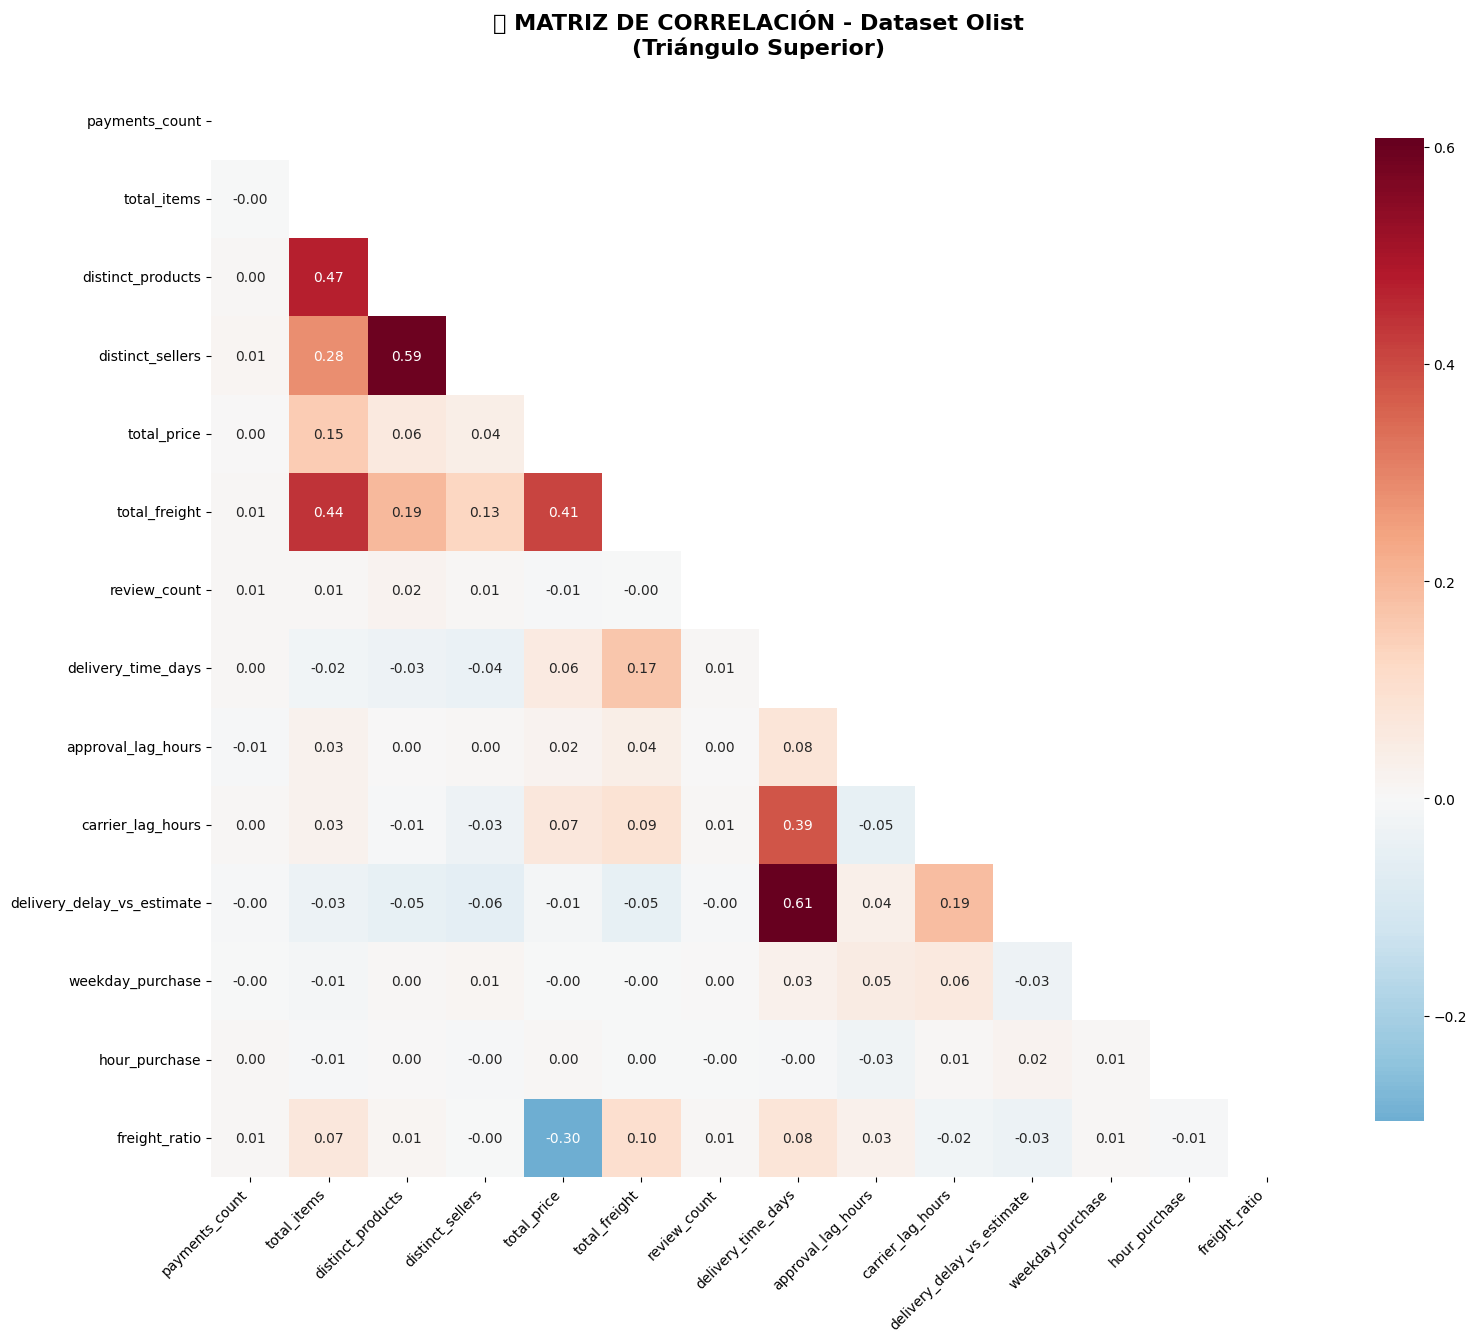

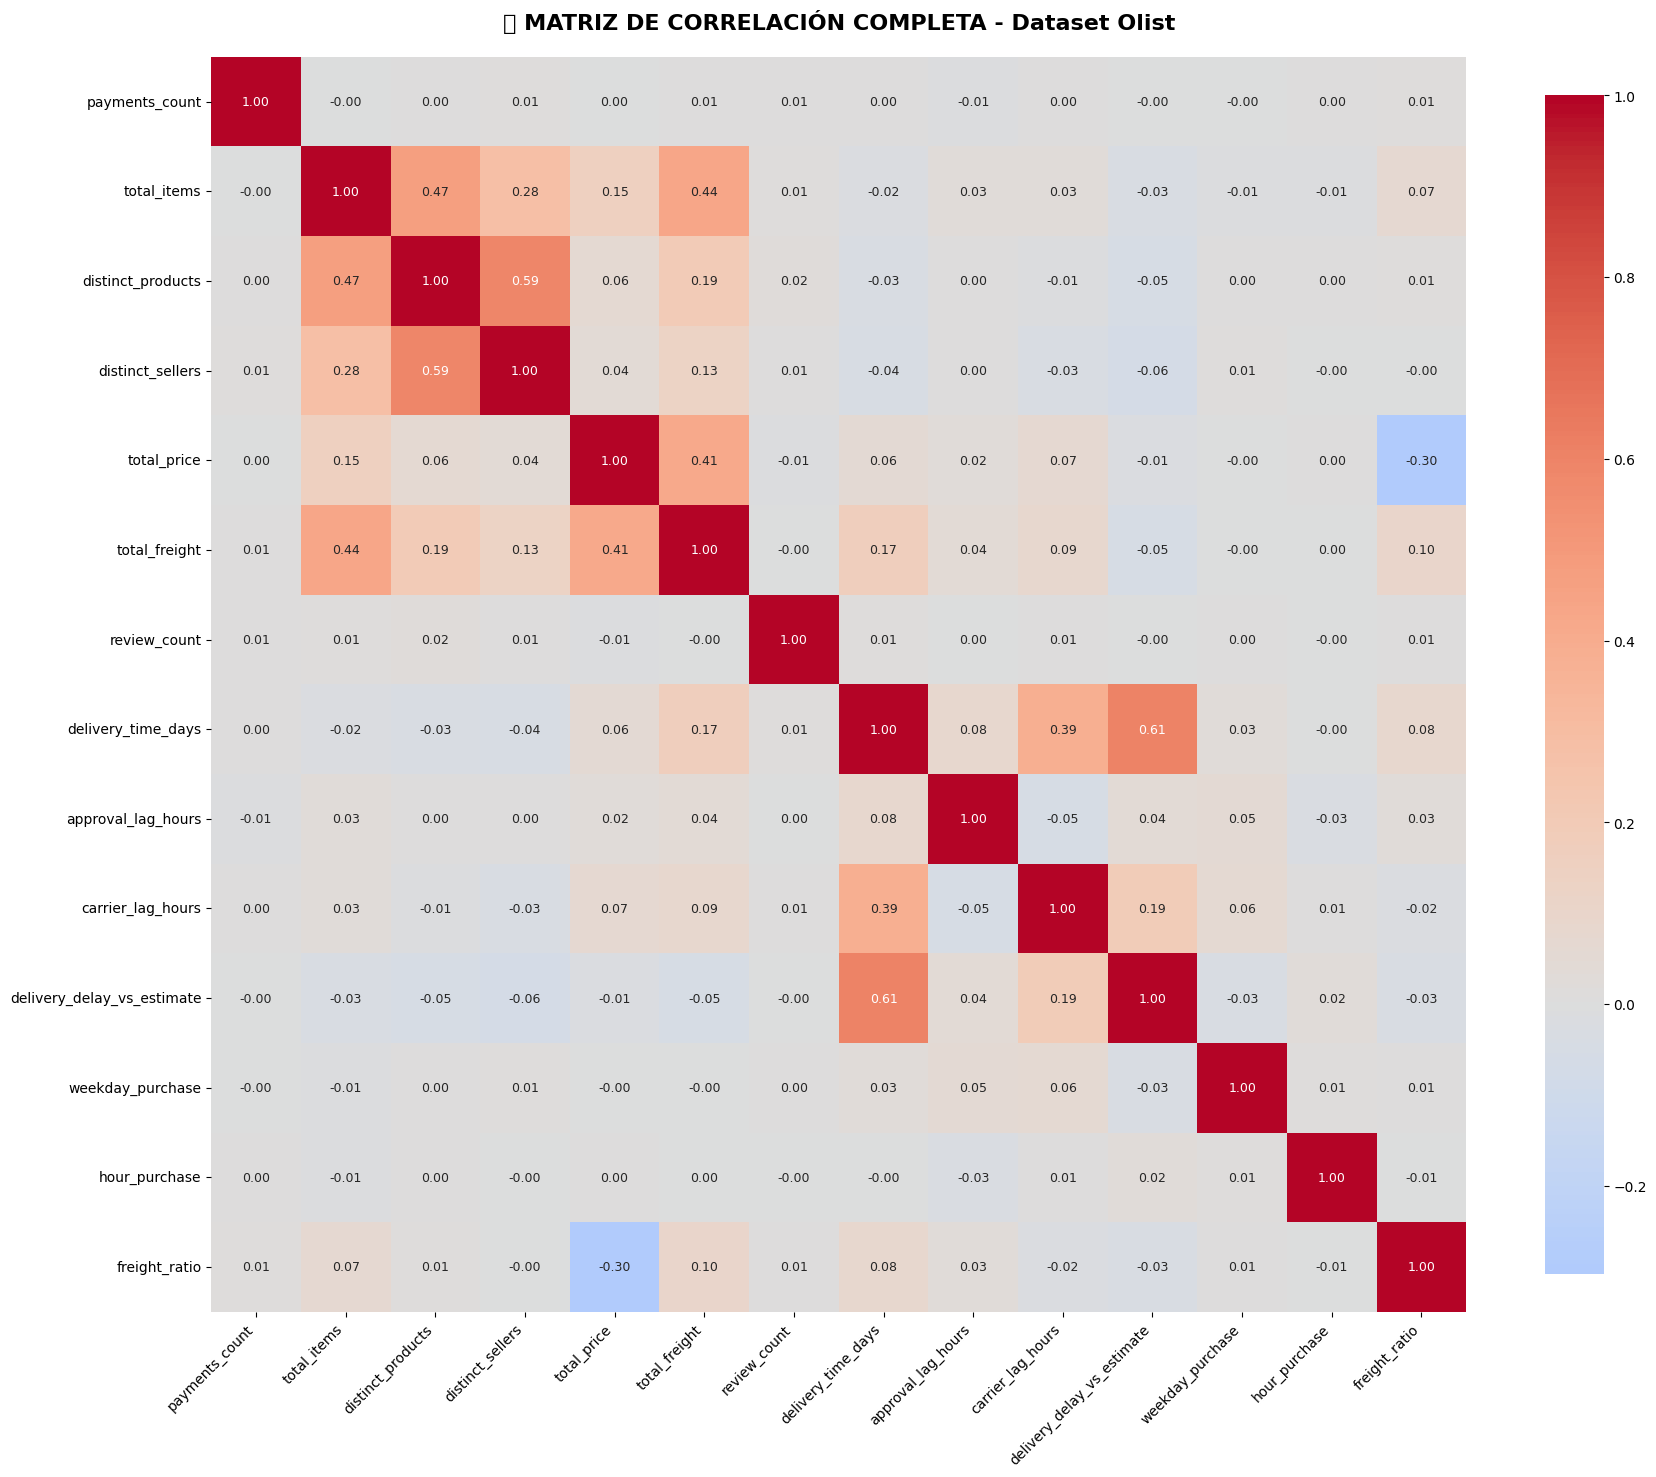


🏆 TOP 20 CORRELACIONES MÁS FUERTES:


,Variable 1,Variable 2,Correlación,Tipo,Fuerza
0,delivery_time_days,delivery_delay_vs_estimate,0.607716,Positiva,Moderada
1,distinct_products,distinct_sellers,0.592784,Positiva,Moderada
2,total_items,distinct_products,0.470977,Positiva,Moderada
3,total_items,total_freight,0.436941,Positiva,Moderada
4,total_freight,total_price,0.412786,Positiva,Moderada
5,carrier_lag_hours,delivery_time_days,0.385048,Positiva,Moderada
6,freight_ratio,total_price,-0.296493,Negativa,Débil
7,total_items,distinct_sellers,0.282200,Positiva,Débil
8,total_freight,distinct_products,0.194978,Positiva,Débil
9,carrier_lag_hours,delivery_delay_vs_estimate,0.189998,Positiva,Débil



🎯 CORRELACIONES CON VARIABLES CLAVE DE NEGOCIO:

📋 Correlaciones con 'delivery_time_days':
   delivery_delay_vs_estimate :   0.608 (🟡 MODERADA)
   carrier_lag_hours         :   0.385 (🟡 MODERADA)
   total_freight             :   0.167 (🟢 DÉBIL)
   approval_lag_hours        :   0.080 (🟢 DÉBIL)
   freight_ratio             :   0.080 (🟢 DÉBIL)

📋 Correlaciones con 'total_price':
   total_freight             :   0.413 (🟡 MODERADA)
   freight_ratio             :  -0.296 (🟢 DÉBIL)
   total_items               :   0.153 (🟢 DÉBIL)
   carrier_lag_hours         :   0.070 (🟢 DÉBIL)
   distinct_products         :   0.061 (🟢 DÉBIL)

📋 Correlaciones con 'freight_ratio':
   total_price               :  -0.296 (🟢 DÉBIL)
   total_freight             :   0.103 (🟢 DÉBIL)
   delivery_time_days        :   0.080 (🟢 DÉBIL)
   total_items               :   0.068 (🟢 DÉBIL)
   delivery_delay_vs_estimate :  -0.032 (🟢 DÉBIL)


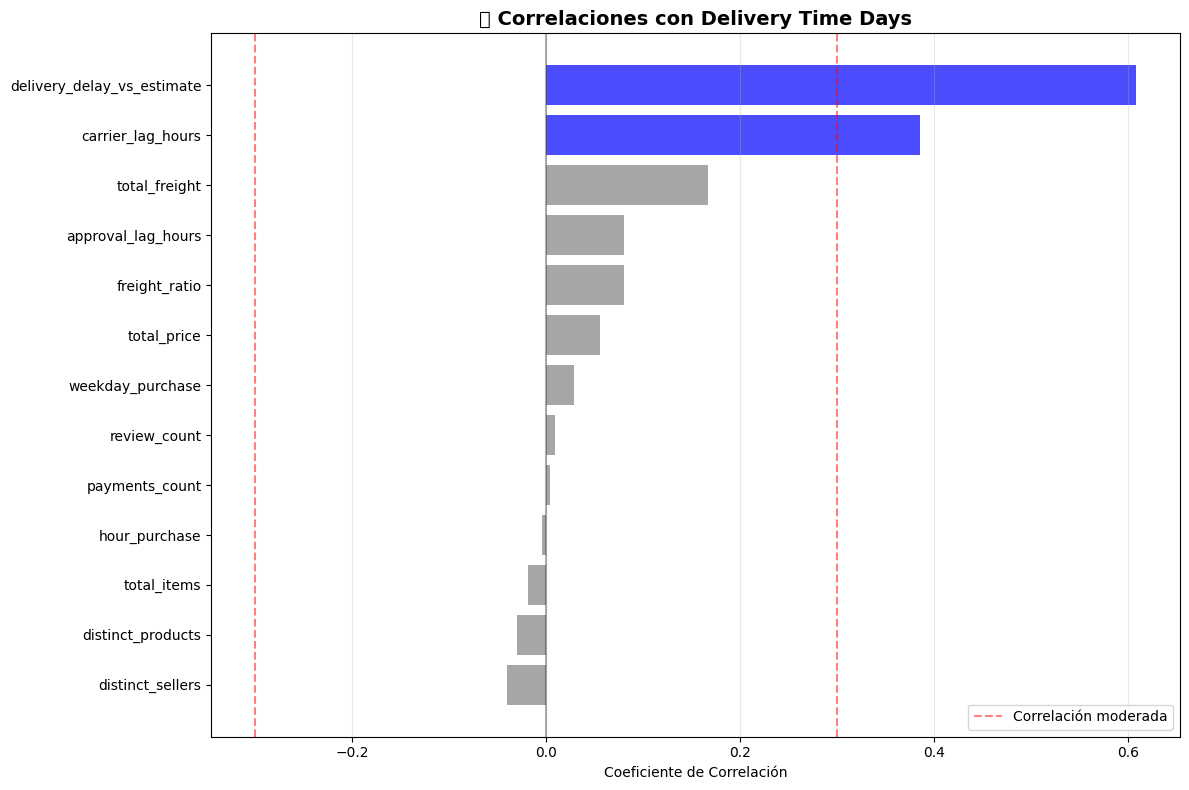

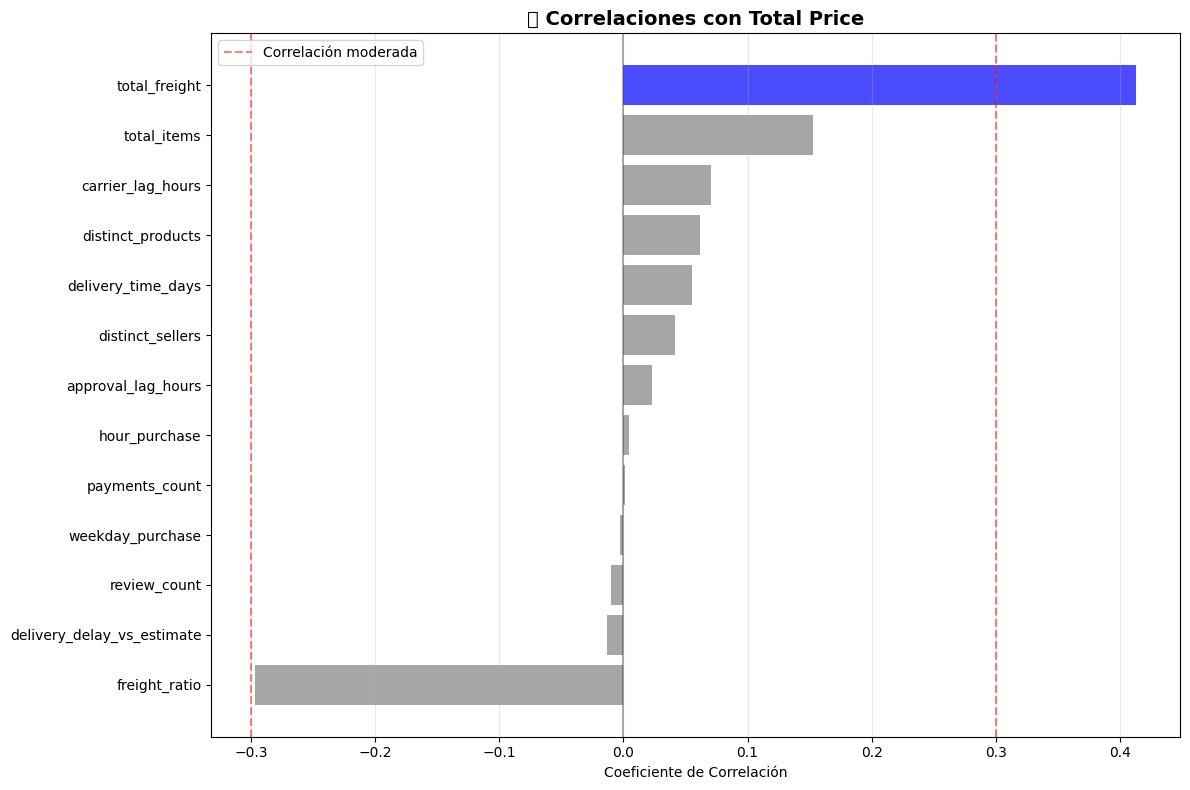


⚠️  ANÁLISIS DE MULTICOLINEALIDAD:
✅ No se detectaron pares con correlación muy alta (>0.8)

📊 RESUMEN ESTADÍSTICO DE CORRELACIONES:
   Total de pares analizados: 91
   Correlación promedio (abs): 0.06663875466273522
   Correlación máxima: 0.6077160203878645
   Correlación mínima: -0.29649334671525174
   Pares con correlación > 0.7: 0
   Pares con correlación > 0.5: 2
   Pares con correlación > 0.3: 6

💾 Matriz de correlación guardada como: 'matriz_correlacion_olist.csv'
ℹ️  La matriz se guardó localmente

🎉 ANÁLISIS DE CORRELACIÓN COMPLETADO


In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
plt.style.use('default')
sns.set_palette("husl")
print("🔍 Analizando matriz de correlación...")

# Cargar el dataset
try:
    df = pd.read_csv('olist_selected_features_clean.csv')
    print(f"✅ Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
except:
    print("❌ No se pudo cargar el archivo. Asegúrate de que existe 'olist_selected_features_clean.csv'")
    # Si no existe, usar los datos de la sesión actual
    if 'selected_features_df' in locals():
        df = selected_features_df
        print("✅ Usando dataset de la sesión actual")
    else:
        raise Exception("No se encontró el dataset. Ejecuta primero el código de limpieza.")

# 1. PREPARACIÓN DE DATOS PARA CORRELACIÓN
print("\n📊 Preparando datos para análisis de correlación...")

# Seleccionar solo columnas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Excluir columnas binarias si se desea (opcional)
binary_columns = ['is_delivered', 'is_canceled', 'delivered_on_time']
numeric_df = numeric_df[[col for col in numeric_df.columns if col not in binary_columns or df[col].nunique() > 2]]

print(f"📈 Columnas numéricas para correlación: {len(numeric_df.columns)}")

# 2. MATRIZ DE CORRELACIÓN BÁSICA
print("\n🧮 Calculando matriz de correlación...")
correlation_matrix = numeric_df.corr()

# 3. VISUALIZACIÓN 1: MATRIZ DE CORRELACIÓN CON HEATMAP
plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # Máscara para triángulo superior

heatmap = sns.heatmap(correlation_matrix,
                      mask=mask,
                      annot=True,
                      fmt=".2f",
                      cmap="RdBu_r",
                      center=0,
                      square=True,
                      cbar_kws={"shrink": .8},
                      annot_kws={"size": 10})

plt.title('🔗 MATRIZ DE CORRELACIÓN - Dataset Olist\n(Triángulo Superior)',
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 4. VISUALIZACIÓN 2: MATRIZ COMPLETA
plt.figure(figsize=(18, 16))
sns.heatmap(correlation_matrix,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            square=True,
            cbar_kws={"shrink": .8},
            annot_kws={"size": 9})

plt.title('🔗 MATRIZ DE CORRELACIÓN COMPLETA - Dataset Olist',
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 5. CORRELACIONES MÁS FUERTES (TOP 20)
print("\n🏆 TOP 20 CORRELACIONES MÁS FUERTES:")

# Crear DataFrame de correlaciones
corr_pairs = correlation_matrix.unstack().sort_values(ascending=False, key=abs)

# Filtrar autocorrelaciones y duplicados
corr_pairs = corr_pairs[corr_pairs < 0.999]  # Remover autocorrelaciones perfectas

# Crear tabla ordenada
top_correlations = []
for idx in range(0, min(40, len(corr_pairs)), 2):  # Tomar pares únicos
    if idx < len(corr_pairs):
        pair = corr_pairs.index[idx]
        value = corr_pairs.iloc[idx]
        if pair[0] != pair[1]:  # Evitar duplicados
            top_correlations.append({
                'Variable 1': pair[0],
                'Variable 2': pair[1],
                'Correlación': value,
                'Tipo': 'Positiva' if value > 0 else 'Negativa',
                'Fuerza': 'Fuerte' if abs(value) > 0.7 else
                         'Moderada' if abs(value) > 0.3 else 'Débil'
            })

top_corr_df = pd.DataFrame(top_correlations).head(20)
display(top_corr_df)

# 6. CORRELACIONES CON VARIABLES CLAVE
print("\n🎯 CORRELACIONES CON VARIABLES CLAVE DE NEGOCIO:")

key_variables = ['delivery_time_days', 'total_price', 'delivered_on_time',
                 'is_delivered', 'is_canceled', 'freight_ratio']

for key_var in key_variables:
    if key_var in correlation_matrix.columns:
        print(f"\n📋 Correlaciones con '{key_var}':")
        corrs_with_key = correlation_matrix[key_var].sort_values(ascending=False, key=abs)
        corrs_with_key = corrs_with_key[corrs_with_key.index != key_var]  # Excluir autocorrelación
        for var, corr in corrs_with_key.head(5).items():
            strength = "🔴 FUERTE" if abs(corr) > 0.7 else "🟡 MODERADA" if abs(corr) > 0.3 else "🟢 DÉBIL"
            print(f"   {var:25} : {corr:7.3f} ({strength})")

# 7. VISUALIZACIÓN 3: CORRELACIONES CON DELIVERY TIME (si existe)
if 'delivery_time_days' in correlation_matrix.columns:
    plt.figure(figsize=(12, 8))
    delivery_corrs = correlation_matrix['delivery_time_days'].drop('delivery_time_days')
    delivery_corrs = delivery_corrs.sort_values(ascending=True)

    colors = ['red' if x < -0.3 else 'blue' if x > 0.3 else 'gray' for x in delivery_corrs]

    plt.barh(delivery_corrs.index, delivery_corrs.values, color=colors, alpha=0.7)
    plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
    plt.axvline(x=0.3, color='red', linestyle='--', alpha=0.5, label='Correlación moderada')
    plt.axvline(x=-0.3, color='red', linestyle='--', alpha=0.5)
    plt.xlabel('Coeficiente de Correlación')
    plt.title('📦 Correlaciones con Delivery Time Days', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 8. VISUALIZACIÓN 4: CORRELACIONES CON TOTAL PRICE (si existe)
if 'total_price' in correlation_matrix.columns:
    plt.figure(figsize=(12, 8))
    price_corrs = correlation_matrix['total_price'].drop('total_price')
    price_corrs = price_corrs.sort_values(ascending=True)

    colors = ['red' if x < -0.3 else 'blue' if x > 0.3 else 'gray' for x in price_corrs]

    plt.barh(price_corrs.index, price_corrs.values, color=colors, alpha=0.7)
    plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
    plt.axvline(x=0.3, color='red', linestyle='--', alpha=0.5, label='Correlación moderada')
    plt.axvline(x=-0.3, color='red', linestyle='--', alpha=0.5)
    plt.xlabel('Coeficiente de Correlación')
    plt.title('💰 Correlaciones con Total Price', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 9. ANÁLISIS DE MULTICOLINEALIDAD
print("\n⚠️  ANÁLISIS DE MULTICOLINEALIDAD:")
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:  # Umbral para multicolinealidad alta
            high_corr_pairs.append({
                'Variable 1': correlation_matrix.columns[i],
                'Variable 2': correlation_matrix.columns[j],
                'Correlación': correlation_matrix.iloc[i, j]
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs)
    print("🚨 Pares con alta correlación (posible multicolinealidad):")
    display(high_corr_df)
else:
    print("✅ No se detectaron pares con correlación muy alta (>0.8)")

# 10. RESUMEN ESTADÍSTICO DE CORRELACIONES
print("\n📊 RESUMEN ESTADÍSTICO DE CORRELACIONES:")
corr_values = correlation_matrix.values[np.triu_indices_from(correlation_matrix.values, k=1)]
summary_stats = {
    'Total de pares analizados': len(corr_values),
    'Correlación promedio (abs)': np.mean(np.abs(corr_values)),
    'Correlación máxima': np.max(corr_values),
    'Correlación mínima': np.min(corr_values),
    'Pares con correlación > 0.7': np.sum(np.abs(corr_values) > 0.7),
    'Pares con correlación > 0.5': np.sum(np.abs(corr_values) > 0.5),
    'Pares con correlación > 0.3': np.sum(np.abs(corr_values) > 0.3),
}

for stat, value in summary_stats.items():
    print(f"   {stat}: {value}")

# 11. GUARDAR MATRIZ DE CORRELACIÓN
correlation_matrix.to_csv('matriz_correlacion_olist.csv')
print(f"\n💾 Matriz de correlación guardada como: 'matriz_correlacion_olist.csv'")

# Opcional: Descargar la matriz
try:
    files.download('matriz_correlacion_olist.csv')
    print("✅ Matriz de correlación descargada")
except:
    print("ℹ️  La matriz se guardó localmente")

print("\n🎉 ANÁLISIS DE CORRELACIÓN COMPLETADO")

hoa


2.Incorporando OTRAS las columnas TALVEZ